# Patent Metrics — Validation & Visualization

Loads every patent output (`patent/output/*.parquet`) plus the metadata, merges on `patent_id`, and
renders **face-validity** checks inline: coverage, metric distributions, temporal trends by grant year,
WIPO-sector breakdowns, windowed-consistency checks (C3≤C5≤C10≤C_all, CD across windows), and
cross-metric correlations. There is no external gold standard for patents, so these plots are sanity
checks that the metrics behave as expected (citation truncation for recent years, F/E/G summing to 1,
examiner/applicant split, etc.).

## Inputs
```
notebook/patent/output/patent_metadata.parquet        # patent_id, grant_year, filing_year, ref_count, cpc_code
notebook/patent/output/patent_citation.parquet        # C_{3,5,10,all} + examiner/applicant/other per window
notebook/patent/output/patent_disruption.parquet      # CD/F/E/G/ni/nj/nk per window
notebook/patent/output/patent_z_score.parquet         # Z_median, Z_10pct, Z_min, n_pairs
notebook/patent/output/patent_hit_probability.parquet # wipo_sector, grant_year, pctl_{c3,c5,c10,call}
```
All figures are shown inline.

In [1]:
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

for _ in range(6):
    if os.path.isdir(os.path.join('notebook', 'patent', 'output')): break
    os.chdir('..')
ROOT = os.getcwd(); print('ROOT:', ROOT)
POUT = os.path.join(ROOT, 'notebook', 'patent', 'output')
YR_LO, YR_HI = 1976, 2024      # sane grant-year range for trend plots

ROOT: C:\Users\jdwoo\OneDrive\Desktop\Research\Science of Science


## 1. Load all patent outputs and merge on `patent_id`

In [2]:
%%time
meta = pd.read_parquet(os.path.join(POUT, 'patent_metadata.parquet'),
                       columns=['patent_id', 'grant_year', 'filing_year', 'ref_count', 'cpc_code'])
cit  = pd.read_parquet(os.path.join(POUT, 'patent_citation.parquet'))
disr = pd.read_parquet(os.path.join(POUT, 'patent_disruption.parquet'))
zsc  = pd.read_parquet(os.path.join(POUT, 'patent_z_score.parquet'))
hit  = pd.read_parquet(os.path.join(POUT, 'patent_hit_probability.parquet'),
                       columns=['patent_id', 'wipo_sector', 'pctl_c3', 'pctl_c5', 'pctl_c10', 'pctl_call'])
sb   = pd.read_parquet(os.path.join(POUT, 'patent_sb.parquet'), columns=['patent_id', 'SB_B', 'SB_T', 'n_cite'])
print('rows:', {'meta': len(meta), 'cit': len(cit), 'disr': len(disr), 'z': len(zsc), 'hit': len(hit), 'sb': len(sb)})

df = meta.merge(cit, on='patent_id', how='left') \
         .merge(disr, on='patent_id', how='left') \
         .merge(zsc, on='patent_id', how='left') \
         .merge(hit, on='patent_id', how='left') \
         .merge(sb, on='patent_id', how='left')
# fill citation windows with 0 where the citation file had no row (no forward citations)
for c in [x for x in df.columns if x.startswith(('C_', 'appC', 'uniqueC'))]:
    df[c] = df[c].fillna(0)
df['cpc_section'] = df['cpc_code'].astype(str).str[0]   # CPC section = first CPC letter (A-H, Y)
print('merged:', df.shape)
df.head(3)

rows: {'meta': 8531961, 'cit': 7160531, 'disr': 8062166, 'z': 4160856, 'hit': 8512715, 'sb': 6803034}


merged: (8531961, 86)
CPU times: total: 46.6 s
Wall time: 37.3 s


,patent_id,grant_year,filing_year,ref_count,cpc_code,C_3,C_5,C_10,C_all,C_examiner_3,...,n_pairs,wipo_sector,pctl_c3,pctl_c5,pctl_c10,pctl_call,SB_B,SB_T,n_cite,cpc_section
0,10000000,2018,2015.0,2,G01S7/4863,4.0,10.0,19.0,19.0,2.0,...,NaN,Instruments,0.899643,0.922765,0.934123,0.934123,3.714286,5.0,19.0,G
1,10000001,2018,2015.0,6,B29C45/64,0.0,0.0,0.0,0.0,0.0,...,1.0,Mechanical engineering,0.000020,0.000020,0.000020,0.000020,NaN,NaN,NaN,B
2,10000002,2018,2014.0,3,B29C48/21,0.0,0.0,0.0,0.0,0.0,...,6.0,Chemistry,0.000024,0.000024,0.000024,0.000024,NaN,NaN,NaN,B


## 2. Coverage — how many patents have each metric defined

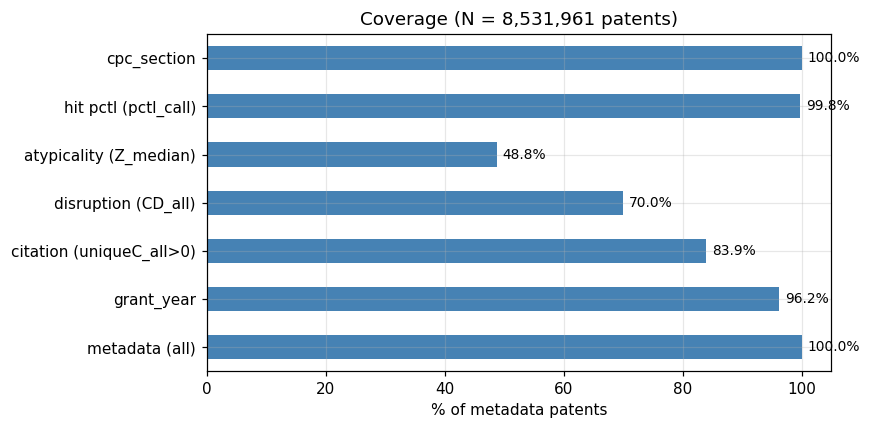

,coverage_%
metadata (all),100.0
grant_year,96.2
citation (uniqueC_all>0),83.9
disruption (CD_all),70.0
atypicality (Z_median),48.8
hit pctl (pctl_call),99.8
cpc_section,100.0


In [3]:
metrics_cov = {
    'metadata (all)': df['patent_id'].notna(),
    'grant_year':     df['grant_year'].between(YR_LO, YR_HI),
    'citation (uniqueC_all>0)': df['uniqueC_all'] > 0,
    'disruption (CD_all)': df['CD_all'].notna(),
    'atypicality (Z_median)': df['Z_median'].notna(),
    'hit pctl (pctl_call)': df['pctl_call'].notna(),
    'cpc_section': df['cpc_section'].notna(),
}
cov = pd.Series({k: v.mean() * 100 for k, v in metrics_cov.items()})
fig, ax = plt.subplots(figsize=(8, 4))
cov.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('% of metadata patents'); ax.set_title(f'Coverage (N = {len(df):,} patents)')
for i, v in enumerate(cov.values): ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlim(0, 105); plt.tight_layout(); plt.show()
display(cov.round(1).to_frame('coverage_%'))

## 3. Grant-year & filing→grant lag

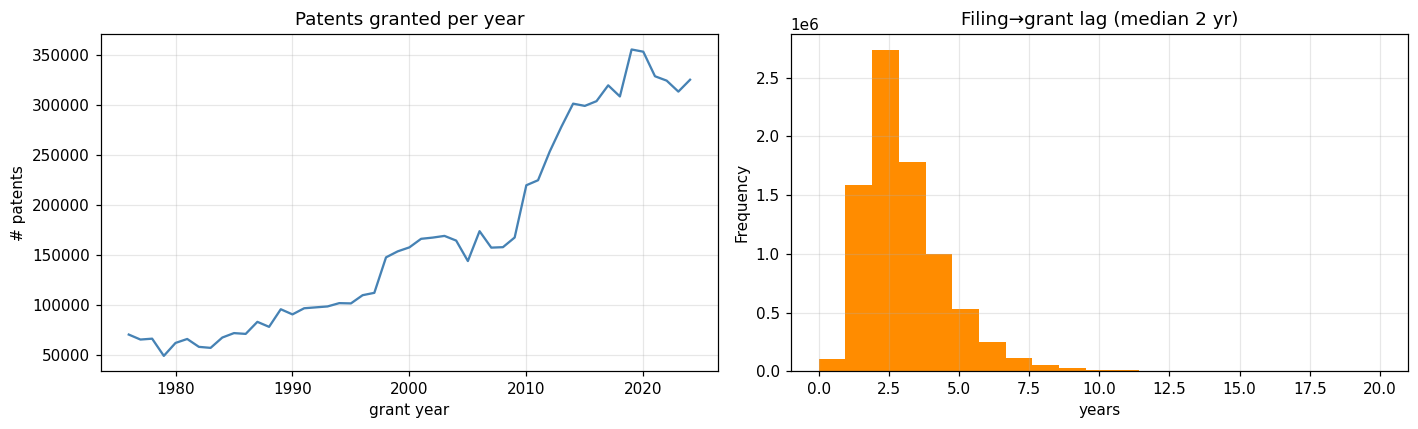

In [4]:
d = df[df['grant_year'].between(YR_LO, YR_HI)]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
d['grant_year'].value_counts().sort_index().plot(ax=ax[0], color='steelblue')
ax[0].set_title('Patents granted per year'); ax[0].set_xlabel('grant year'); ax[0].set_ylabel('# patents')
lag = (d['grant_year'] - d['filing_year'])
lag = lag[(lag >= 0) & (lag <= 20)]
lag.plot.hist(bins=21, ax=ax[1], color='darkorange')
ax[1].set_title(f'Filing→grant lag (median {lag.median():.0f} yr)'); ax[1].set_xlabel('years')
plt.tight_layout(); plt.show()

## 4. Forward-citation (UNIQUE / de-duplicated) distributions + windowed monotonicity

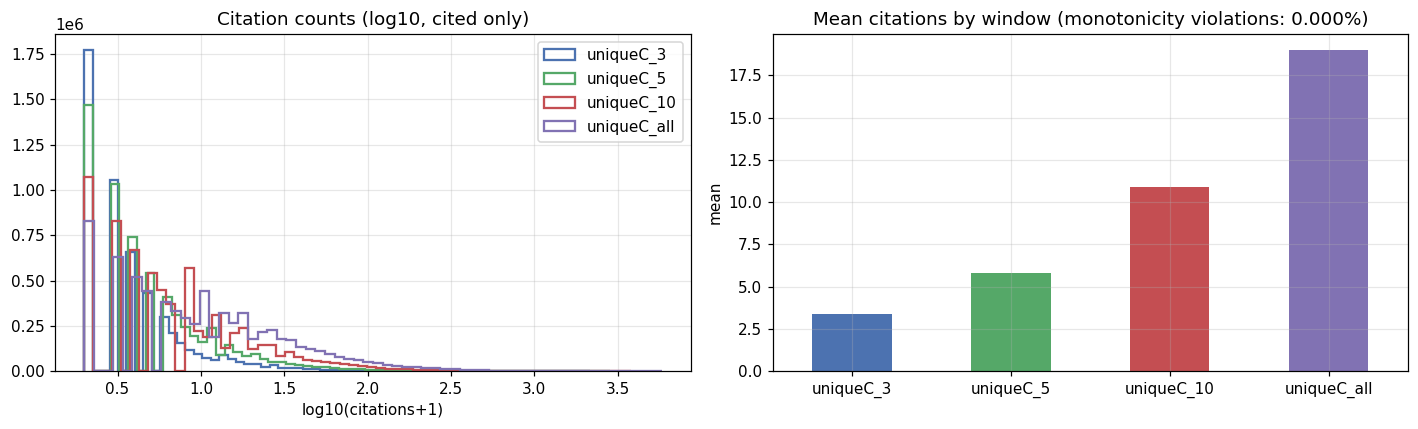

uniqueC_3<=uniqueC_5<=uniqueC_10<=uniqueC_all violations: 0.0000%  (should be 0)


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for c, col in zip(['uniqueC_3', 'uniqueC_5', 'uniqueC_10', 'uniqueC_all'], ['#4c72b0', '#55a868', '#c44e52', '#8172b3']):
    v = df[c][df[c] > 0]
    ax[0].hist(np.log10(v + 1), bins=60, histtype='step', label=c, color=col, linewidth=1.5)
ax[0].set_title('Citation counts (log10, cited only)'); ax[0].set_xlabel('log10(citations+1)'); ax[0].legend()
# monotonicity: uniqueC_3<=uniqueC_5<=uniqueC_10<=uniqueC_all should always hold
viol = ((df['uniqueC_3'] > df['uniqueC_5']) | (df['uniqueC_5'] > df['uniqueC_10']) | (df['uniqueC_10'] > df['uniqueC_all'])).mean() * 100
means = df[['uniqueC_3', 'uniqueC_5', 'uniqueC_10', 'uniqueC_all']].mean()
means.plot.bar(ax=ax[1], color=['#4c72b0', '#55a868', '#c44e52', '#8172b3'])
ax[1].set_title(f'Mean citations by window (monotonicity violations: {viol:.3f}%)')
ax[1].set_ylabel('mean'); plt.setp(ax[1].get_xticklabels(), rotation=0)
plt.tight_layout(); plt.show()
print(f'uniqueC_3<=uniqueC_5<=uniqueC_10<=uniqueC_all violations: {viol:.4f}%  (should be 0)')

## 5. Mean citations by grant year — UNIQUE (de-duplicated) main + examiner/non-examiner split

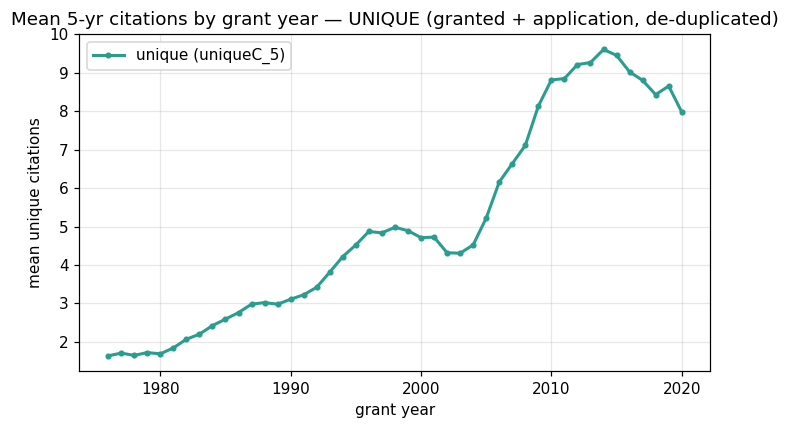

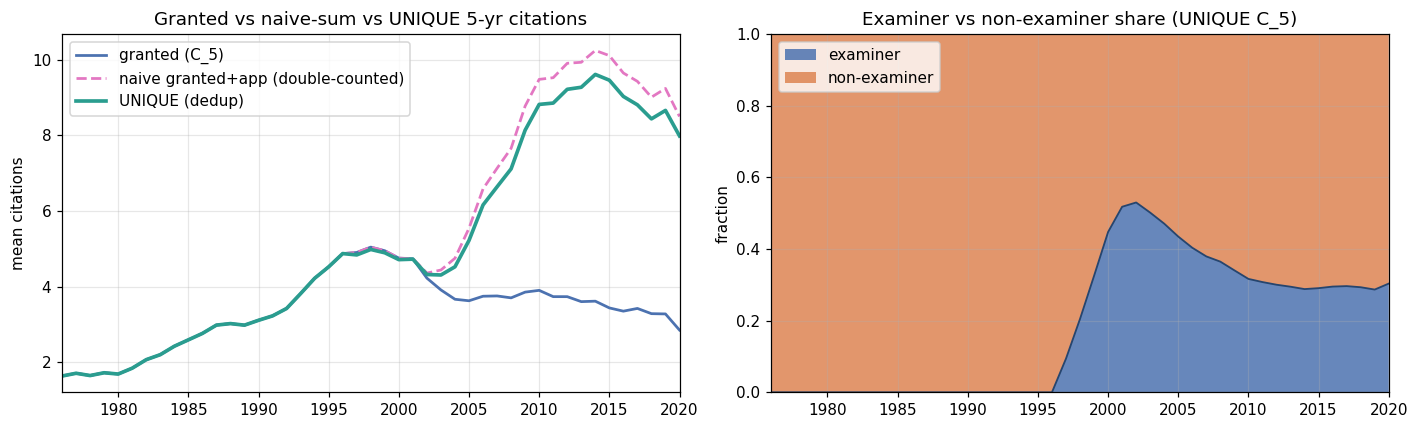

In [6]:
YR5 = 2020                               # C_5 needs a full 5-yr window -> cap grant year at 2020
d = df[df['grant_year'].between(YR_LO, YR5)]
g = d.groupby('grant_year')
# MAIN: mean UNIQUE (granted + application, de-duplicated) 5-yr citations by grant year
uc5 = g['uniqueC_5'].mean()
figg, axg = plt.subplots(figsize=(6.5, 4))
axg.plot(uc5.index, uc5.values, color='#2a9d8f', lw=2, marker='o', ms=3, label='unique (uniqueC_5)')
axg.set_title('Mean 5-yr citations by grant year — UNIQUE (granted + application, de-duplicated)')
axg.set_xlabel('grant year'); axg.set_ylabel('mean unique citations'); axg.legend(loc='upper left')
plt.tight_layout(); plt.show()
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
# dedup effect: granted vs naive granted+application (double-counted) vs unique
gr = g['C_5'].mean(); apc = g['appC_5'].mean(); naive = gr + apc
ax[0].plot(gr.index, gr.values, color='#4c72b0', lw=1.8, label='granted (C_5)')
ax[0].plot(naive.index, naive.values, color='#e377c2', lw=1.8, ls='--', label='naive granted+app (double-counted)')
ax[0].plot(uc5.index, uc5.values, color='#2a9d8f', lw=2.4, label='UNIQUE (dedup)')
ax[0].set_title('Granted vs naive-sum vs UNIQUE 5-yr citations'); ax[0].set_ylabel('mean citations')
ax[0].legend(loc='upper left'); ax[0].set_xlim(YR_LO, YR5)
# examiner vs non-examiner share of UNIQUE citations; drop years with no data
exm = g['uniqueC_examiner_5'].sum(); nex = g['uniqueC_non_examiner_5'].sum()
tot = exm + nex; keep = tot > 0
fe = (exm[keep] / tot[keep]); fn = (nex[keep] / tot[keep])
ax[1].stackplot(fe.index, fe.values, fn.values, labels=['examiner', 'non-examiner'],
                colors=['#4c72b0', '#dd8452'], alpha=0.85)
ax[1].plot(fe.index, fe.values, color='#26456e', lw=1.2)
ax[1].set_title('Examiner vs non-examiner share (UNIQUE C_5)')
ax[1].set_ylabel('fraction'); ax[1].set_ylim(0, 1); ax[1].set_xlim(fe.index.min(), fe.index.max()); ax[1].legend(loc='upper left')
plt.tight_layout(); plt.show()

## 5b. Application citations (pre-grant) by grant year + examiner/non-examiner + granted-vs-application

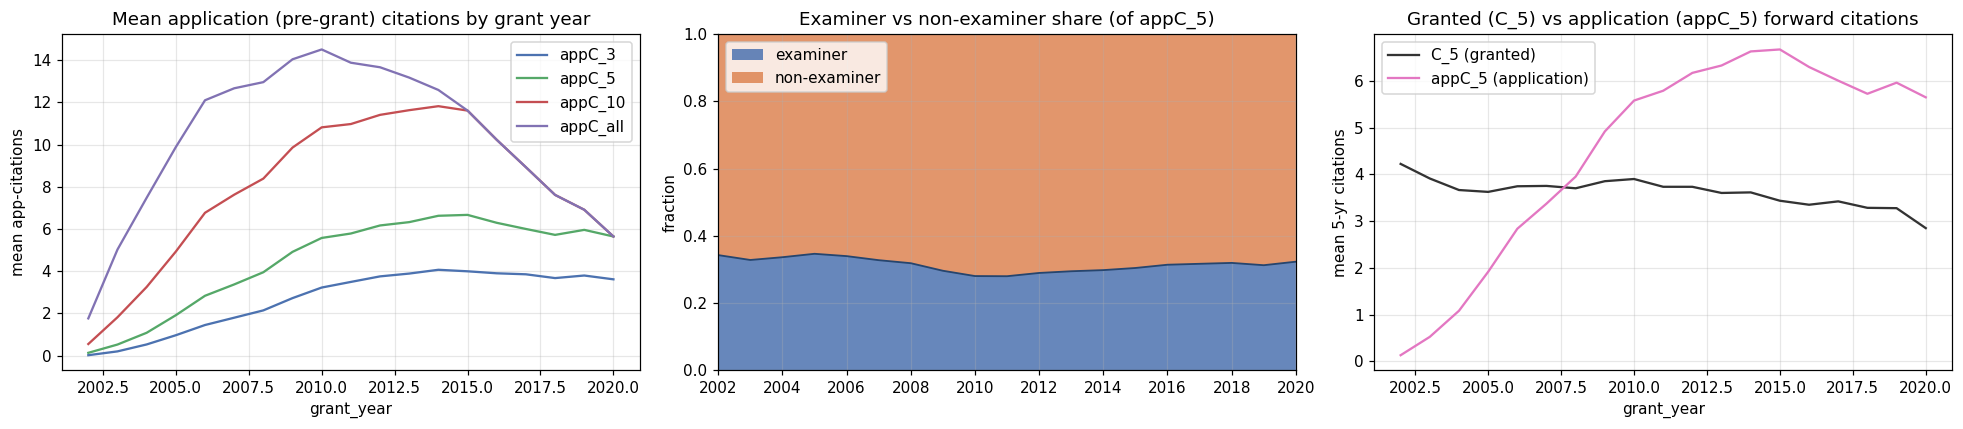

coverage: patents with appC_all>0 = 3828179 / 8531961 (44.9%)


Spearman C_5 vs appC_5 (grant 2002..YR_HI-5): 0.249
  appC_3: mean 2.012  exm/non-exm 0.660/1.352
  appC_5: mean 3.088  exm/non-exm 0.966/2.122
  appC_10: mean 4.868  exm/non-exm 1.389/3.480
  appC_all: mean 5.807  exm/non-exm 1.579/4.227


In [7]:
# Application (pre-grant) forward citations: appC_{3,5,10,all}, from g_us_application_citation
# mapped pgpub->patent via pg_granted_pgpubs_crosswalk. Pre-grant publications begin ~2001,
# so app-citations are ~0 before then; restrict the trend to grant years >= 2002.
d = df[df['grant_year'].between(2002, 2020)]      # pgpub era .. C_5 full-window cap
g = d.groupby('grant_year')
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
for c, col in zip(['appC_3', 'appC_5', 'appC_10', 'appC_all'], ['#4c72b0', '#55a868', '#c44e52', '#8172b3']):
    g[c].mean().plot(ax=ax[0], label=c, color=col)
ax[0].set_title('Mean application (pre-grant) citations by grant year'); ax[0].set_ylabel('mean app-citations'); ax[0].legend()
exm = g['appC_examiner_5'].sum(); nex = g['appC_non_examiner_5'].sum()
tot = exm + nex; keep = tot > 0
fe = (exm[keep] / tot[keep]); fn = (nex[keep] / tot[keep])
ax[1].stackplot(fe.index, fe.values, fn.values, labels=['examiner', 'non-examiner'],
                colors=['#4c72b0', '#dd8452'], alpha=0.85)
ax[1].plot(fe.index, fe.values, color='#26456e', lw=1.2)
ax[1].set_title('Examiner vs non-examiner share (of appC_5)'); ax[1].set_ylabel('fraction')
ax[1].set_ylim(0, 1); ax[1].set_xlim(fe.index.min(), fe.index.max()); ax[1].legend(loc='upper left')
g[['C_5', 'appC_5']].mean().plot(ax=ax[2], color=['#333333', '#e377c2'])
ax[2].set_title('Granted (C_5) vs application (appC_5) forward citations'); ax[2].set_ylabel('mean 5-yr citations')
ax[2].legend(['C_5 (granted)', 'appC_5 (application)'])
plt.tight_layout(); plt.show()
sub = df[df['grant_year'].between(2002, YR_HI - 5)]
print('coverage: patents with appC_all>0 =', int((df['appC_all'] > 0).sum()), '/', len(df),
      f"({100*(df['appC_all']>0).mean():.1f}%)")
print('Spearman C_5 vs appC_5 (grant 2002..YR_HI-5):',
      round(sub[['C_5', 'appC_5']].corr(method='spearman').iloc[0, 1], 3))
for s in ['_3', '_5', '_10', '_all']:
    print(f'  appC{s}: mean {df[f"appC{s}"].mean():.3f}  '
          f'exm/non-exm {df[f"appC_examiner{s}"].mean():.3f}/{df[f"appC_non_examiner{s}"].mean():.3f}')

## 6. Disruption (CD) — distribution, trend, ni/nj/nk composition

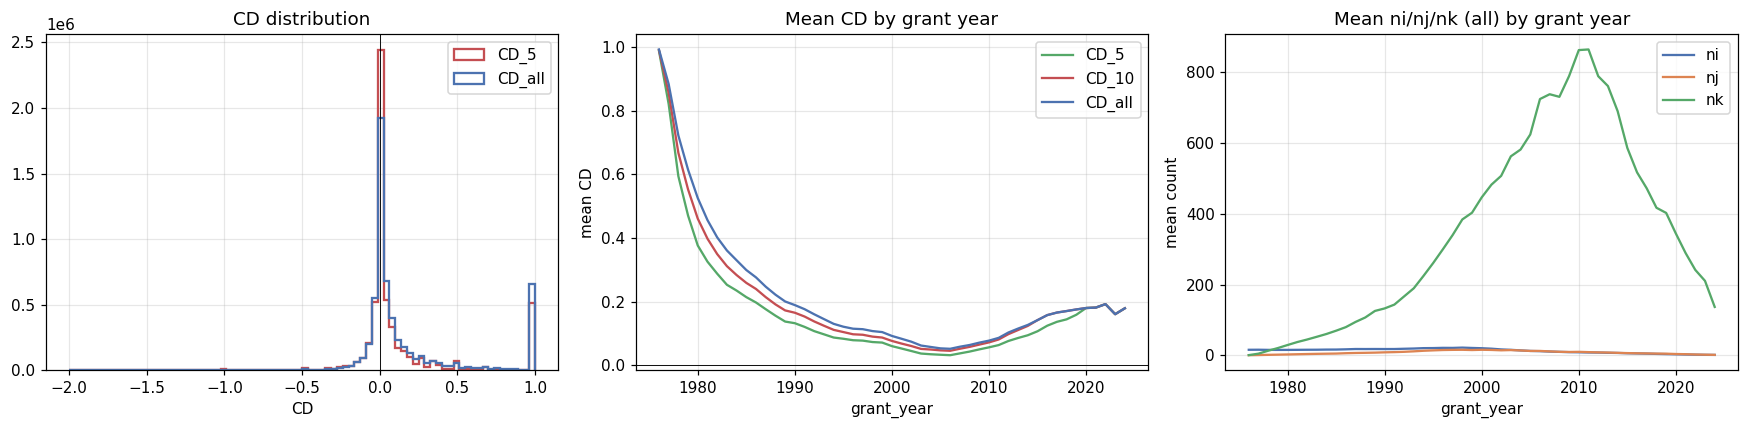

CD_all summary:


count    5.973424e+06
mean     1.691000e-01
std      3.389000e-01
min     -2.000000e+00
25%     -2.100000e-03
50%      2.500000e-02
75%      1.731000e-01
max      1.000000e+00


In [8]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for c, col in zip(['CD_5', 'CD_all'], ['#c44e52', '#4c72b0']):
    ax[0].hist(df[c].dropna(), bins=80, histtype='step', label=c, color=col, linewidth=1.5)
ax[0].set_title('CD distribution'); ax[0].set_xlabel('CD'); ax[0].legend(); ax[0].axvline(0, color='k', lw=0.6)
d = df[df['grant_year'].between(YR_LO, YR_HI)]
g = d.groupby('grant_year')
for c, col in zip(['CD_5', 'CD_10', 'CD_all'], ['#55a868', '#c44e52', '#4c72b0']):
    g[c].mean().plot(ax=ax[1], label=c, color=col)
ax[1].set_title('Mean CD by grant year'); ax[1].set_ylabel('mean CD'); ax[1].axhline(0, color='k', lw=0.6); ax[1].legend()
comp = g[['ni_all', 'nj_all', 'nk_all']].mean()
comp.plot(ax=ax[2], color=['#4c72b0', '#dd8452', '#55a868'])
ax[2].set_title('Mean ni/nj/nk (all) by grant year'); ax[2].set_ylabel('mean count'); ax[2].legend(['ni', 'nj', 'nk'])
plt.tight_layout(); plt.show()
print('CD_all summary:'); print(df['CD_all'].describe().round(4).to_string())

## 7. F/E/G (Foundation / Extension / Generalization)

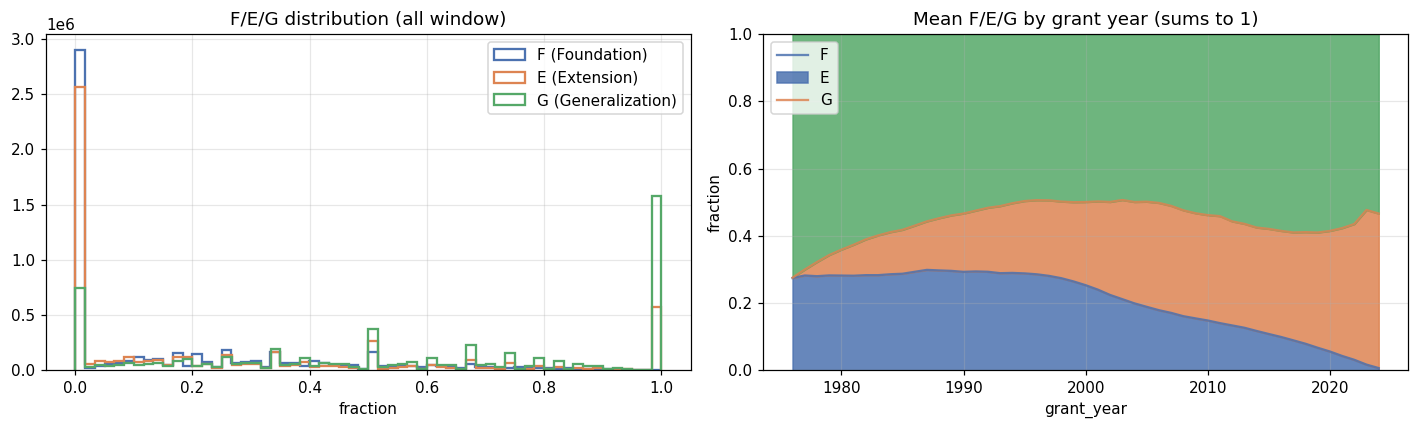

mean F/E/G (all): {'F_all': 0.1850000023841858, 'E_all': 0.2669999897480011, 'G_all': 0.5479999780654907} | sum = 1.0


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for c, lab, col in [('F_all', 'F (Foundation)', '#4c72b0'), ('E_all', 'E (Extension)', '#dd8452'),
                    ('G_all', 'G (Generalization)', '#55a868')]:
    ax[0].hist(df[c].dropna(), bins=60, histtype='step', label=lab, color=col, linewidth=1.5)
ax[0].set_title('F/E/G distribution (all window)'); ax[0].set_xlabel('fraction'); ax[0].legend()
d = df[df['grant_year'].between(YR_LO, YR_HI)]
feg = d.groupby('grant_year')[['F_all', 'E_all', 'G_all']].mean()
feg.plot.area(ax=ax[1], color=['#4c72b0', '#dd8452', '#55a868'], alpha=0.85)
ax[1].set_title('Mean F/E/G by grant year (sums to 1)'); ax[1].set_ylabel('fraction'); ax[1].set_ylim(0, 1)
ax[1].legend(['F', 'E', 'G'], loc='upper left'); plt.tight_layout(); plt.show()
print('mean F/E/G (all):', df[['F_all', 'E_all', 'G_all']].mean().round(3).to_dict(),
      '| sum =', round(df[['F_all', 'E_all', 'G_all']].mean().sum(), 3))

## 8. Atypicality (z-scores)

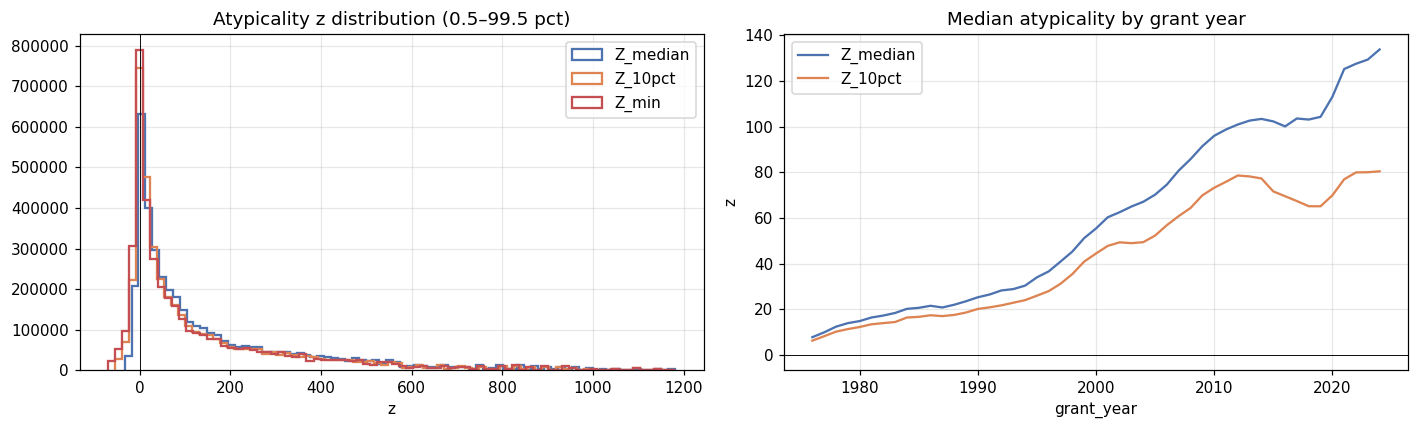

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for c, col in zip(['Z_median', 'Z_10pct', 'Z_min'], ['#4c72b0', '#dd8452', '#c44e52']):
    v = df[c].replace([np.inf, -np.inf], np.nan).dropna()
    v = v[(v > v.quantile(0.005)) & (v < v.quantile(0.995))]
    ax[0].hist(v, bins=80, histtype='step', label=c, color=col, linewidth=1.5)
ax[0].set_title('Atypicality z distribution (0.5–99.5 pct)'); ax[0].set_xlabel('z'); ax[0].legend()
ax[0].axvline(0, color='k', lw=0.6)
d = df[df['grant_year'].between(YR_LO, YR_HI)]
d.groupby('grant_year')[['Z_median', 'Z_10pct']].median().plot(ax=ax[1], color=['#4c72b0', '#dd8452'])
ax[1].set_title('Median atypicality by grant year'); ax[1].set_ylabel('z'); ax[1].axhline(0, color='k', lw=0.6)
plt.tight_layout(); plt.show()

## 9. Hit percentile distribution

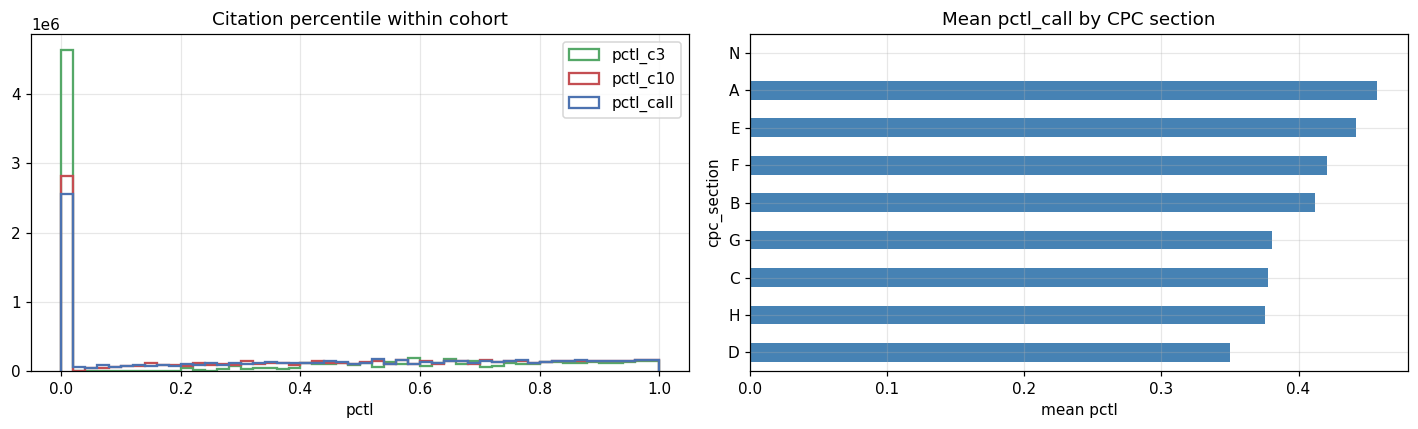

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for c, col in zip(['pctl_c3', 'pctl_c10', 'pctl_call'], ['#55a868', '#c44e52', '#4c72b0']):
    ax[0].hist(df[c].dropna(), bins=50, histtype='step', label=c, color=col, linewidth=1.5)
ax[0].set_title('Citation percentile within cohort'); ax[0].set_xlabel('pctl'); ax[0].legend()
# mean pctl by sector
sec = df.dropna(subset=['cpc_section']).groupby('cpc_section')['pctl_call'].mean().sort_values()
sec.plot.barh(ax=ax[1], color='steelblue'); ax[1].set_title('Mean pctl_call by CPC section'); ax[1].set_xlabel('mean pctl')
plt.tight_layout(); plt.show()

## 10. By CPC section — metric means

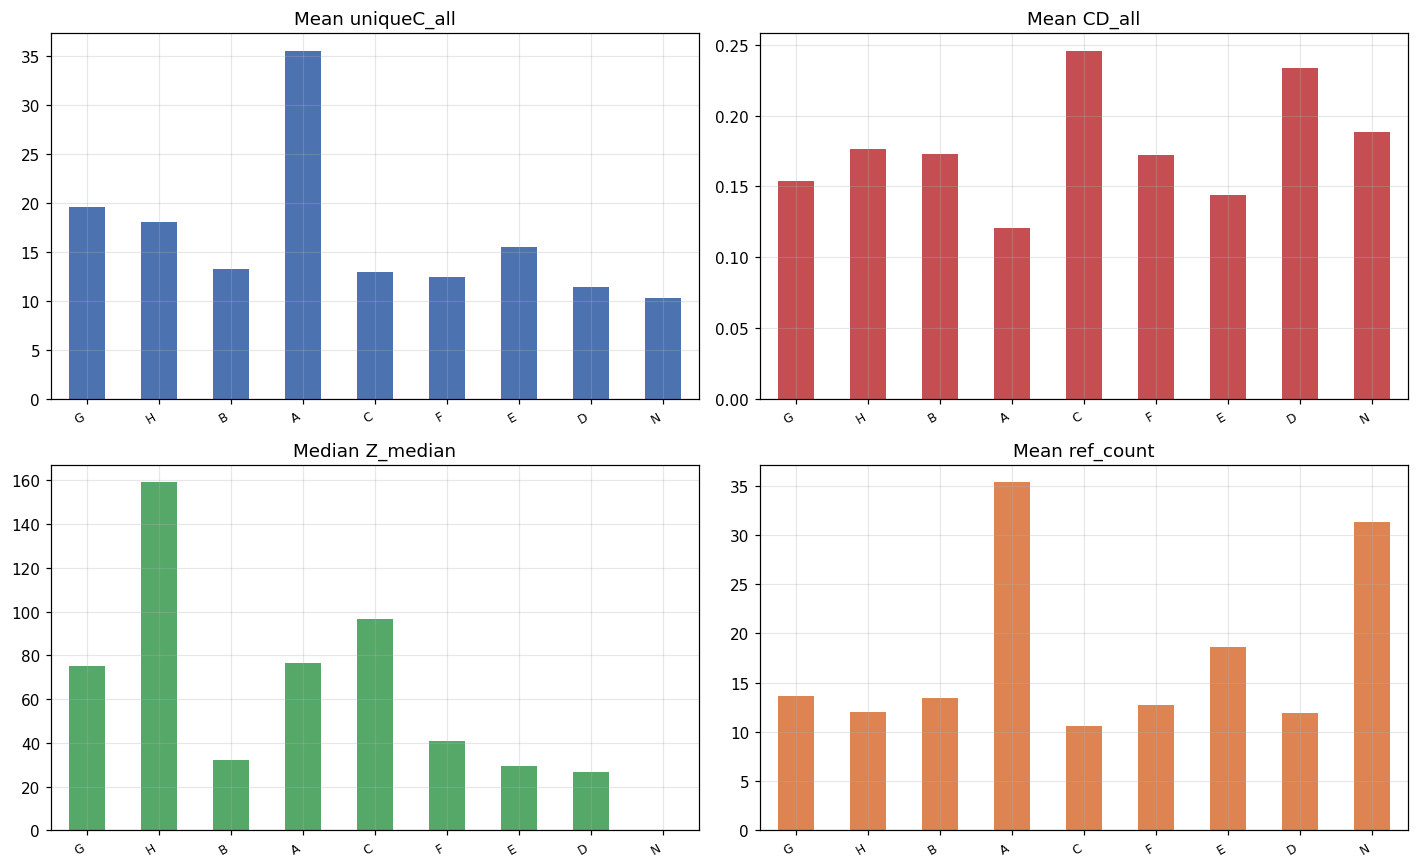

,n,ref_count,uniqueC_all,CD_all,Z_median
cpc_section,,,,,
G,2270328,13.63,19.59,0.15,75.01
H,2124027,12.03,18.07,0.18,159.05
B,1202253,13.40,13.27,0.17,32.35
A,1109395,35.32,35.56,0.12,76.63
C,882753,10.61,12.91,0.25,96.58
F,621659,12.75,12.45,0.17,40.68
E,225421,18.61,15.52,0.14,29.34
D,76893,11.93,11.43,0.23,26.42
N,19232,31.26,10.29,0.19,NaN


In [12]:
d = df.dropna(subset=['cpc_section'])
agg = d.groupby('cpc_section').agg(
    n=('patent_id', 'size'), ref_count=('ref_count', 'mean'), uniqueC_all=('uniqueC_all', 'mean'),
    CD_all=('CD_all', 'mean'), Z_median=('Z_median', 'median')).sort_values('n', ascending=False)
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
agg['uniqueC_all'].plot.bar(ax=ax[0, 0], color='#4c72b0');  ax[0, 0].set_title('Mean uniqueC_all'); ax[0, 0].set_xlabel('')
agg['CD_all'].plot.bar(ax=ax[0, 1], color='#c44e52'); ax[0, 1].set_title('Mean CD_all'); ax[0, 1].axhline(0, color='k', lw=0.6); ax[0, 1].set_xlabel('')
agg['Z_median'].plot.bar(ax=ax[1, 0], color='#55a868'); ax[1, 0].set_title('Median Z_median'); ax[1, 0].axhline(0, color='k', lw=0.6); ax[1, 0].set_xlabel('')
agg['ref_count'].plot.bar(ax=ax[1, 1], color='#dd8452'); ax[1, 1].set_title('Mean ref_count'); ax[1, 1].set_xlabel('')
for a in ax.flat: plt.setp(a.get_xticklabels(), rotation=30, ha='right', fontsize=8)
plt.tight_layout(); plt.show()
display(agg.round(2))

## 11. Cross-metric correlations

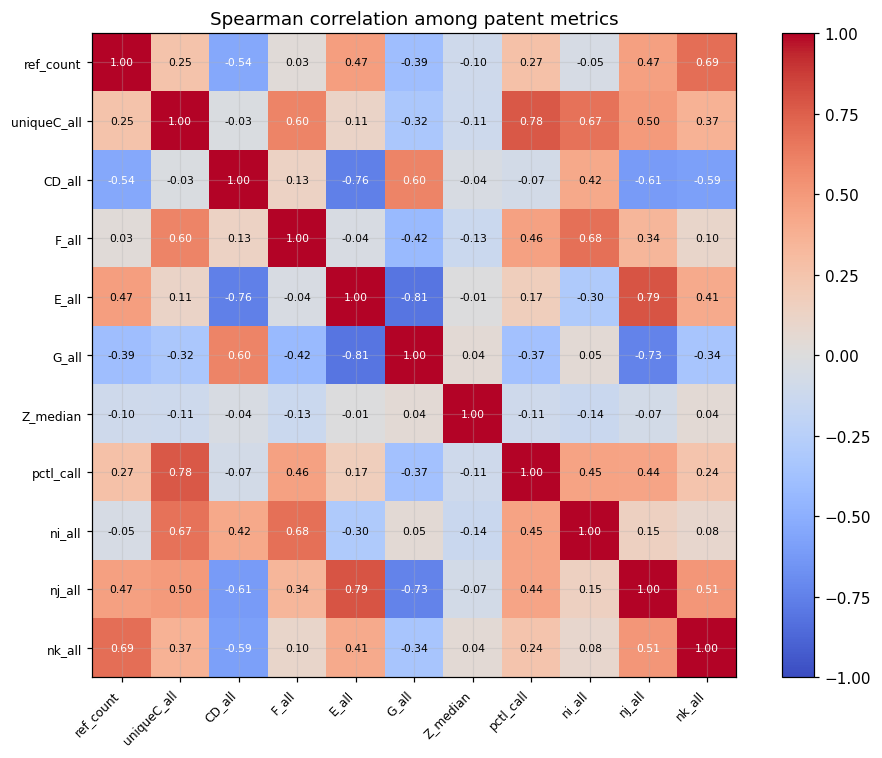

In [13]:
keys = ['ref_count', 'uniqueC_all', 'CD_all', 'F_all', 'E_all', 'G_all', 'Z_median', 'pctl_call', 'ni_all', 'nj_all', 'nk_all']
corr = df[keys].replace([np.inf, -np.inf], np.nan).corr(method='spearman')
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(keys))); ax.set_xticklabels(keys, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(keys))); ax.set_yticklabels(keys, fontsize=8)
for i in range(len(keys)):
    for j in range(len(keys)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')
ax.set_title('Spearman correlation among patent metrics'); fig.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.show()

## 12. Scatter checks (50k sample)

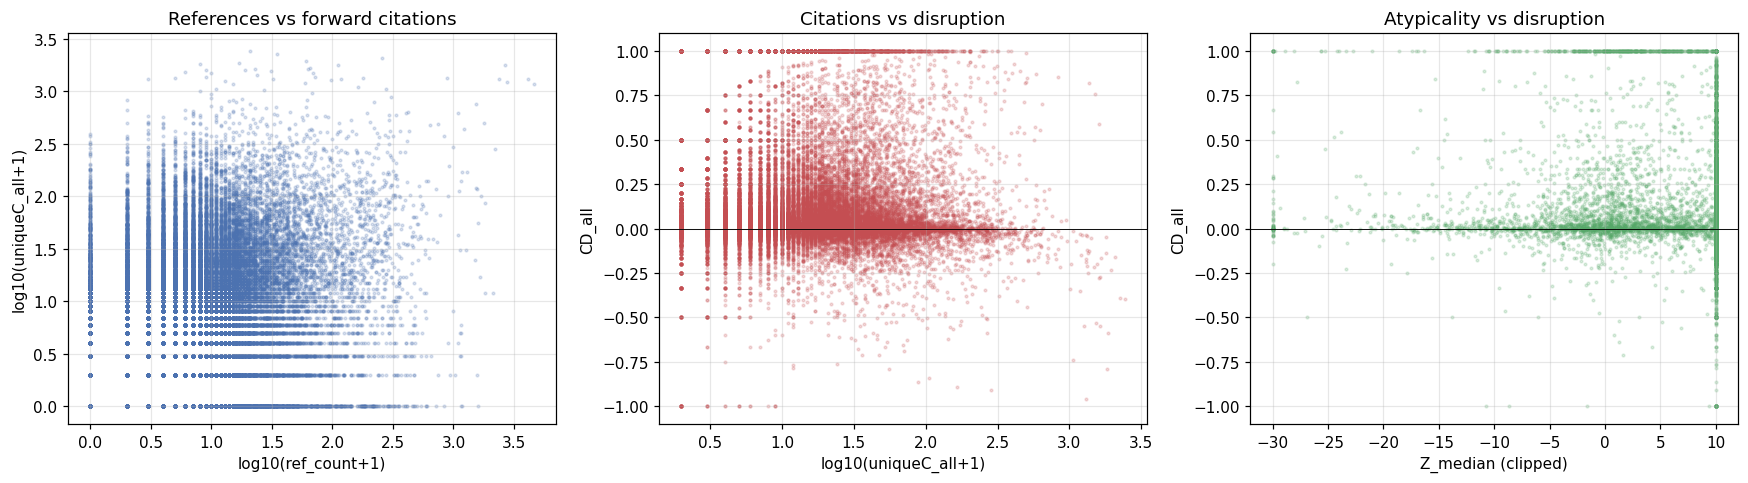

In [14]:
s = df.sample(min(50000, len(df)), random_state=0)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].scatter(np.log10(s['ref_count'] + 1), np.log10(s['uniqueC_all'] + 1), s=3, alpha=0.2, color='#4c72b0')
ax[0].set_xlabel('log10(ref_count+1)'); ax[0].set_ylabel('log10(uniqueC_all+1)'); ax[0].set_title('References vs forward citations')
ax[1].scatter(np.log10(s['uniqueC_all'] + 1), s['CD_all'], s=3, alpha=0.2, color='#c44e52')
ax[1].set_xlabel('log10(uniqueC_all+1)'); ax[1].set_ylabel('CD_all'); ax[1].set_title('Citations vs disruption'); ax[1].axhline(0, color='k', lw=0.6)
ax[2].scatter(s['Z_median'].clip(-30, 10), s['CD_all'], s=3, alpha=0.2, color='#55a868')
ax[2].set_xlabel('Z_median (clipped)'); ax[2].set_ylabel('CD_all'); ax[2].set_title('Atypicality vs disruption'); ax[2].axhline(0, color='k', lw=0.6)
plt.tight_layout(); plt.show()

## 13. Sleeping Beauty (SB_B / SB_T, B vs impact, by sector)

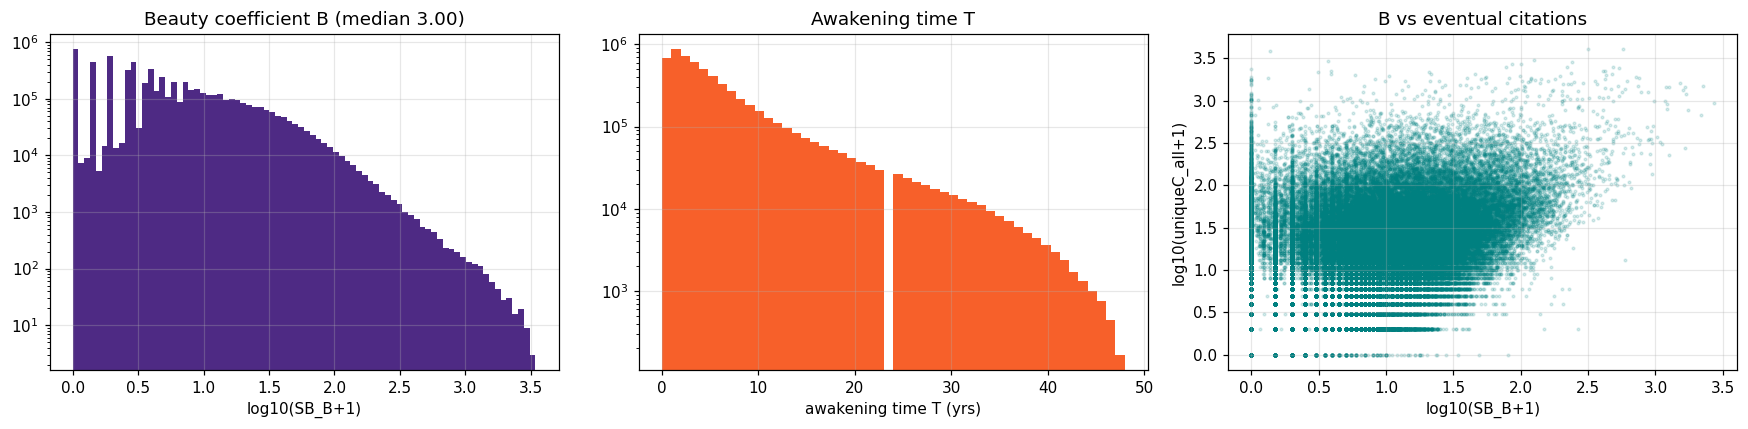

Top sleeping-beauty patents:


,patent_id,grant_year,cpc_section,SB_B,SB_T,n_cite
2712022,4149461,1979,B,3426.562256,42.0,436.0
2535506,3972734,1976,H,3255.237305,42.0,1011.0
2596839,4034143,1977,H,3169.818604,41.0,1009.0
2506960,3944163,1976,B,3076.471191,42.0,1025.0
2813231,4250817,1981,F,3058.821533,41.0,349.0
2855956,4293604,1981,D,3009.550049,38.0,825.0
2716673,4154122,1979,B,2994.076416,39.0,1017.0
2844938,4282573,1981,F,2964.324463,38.0,701.0
2590448,4027746,1977,B,2946.662842,41.0,1027.0
2723401,4160857,1979,H,2938.524170,41.0,601.0


done — all validation figures rendered inline.


In [15]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
b = df['SB_B'].dropna()
ax[0].hist(np.log10(b.clip(lower=0) + 1), bins=80, color='#4E2A84'); ax[0].set_yscale('log')
ax[0].set_xlabel('log10(SB_B+1)'); ax[0].set_title(f'Beauty coefficient B (median {b.median():.2f})')
t = df['SB_T'].dropna().clip(0, 50)
ax[1].hist(t, bins=50, color='#F7602A'); ax[1].set_yscale('log')
ax[1].set_xlabel('awakening time T (yrs)'); ax[1].set_title('Awakening time T')
s = df.dropna(subset=['SB_B', 'uniqueC_all']).sample(min(150000, df['SB_B'].notna().sum()), random_state=0)
ax[2].scatter(np.log10(s['SB_B'].clip(lower=0) + 1), np.log10(s['uniqueC_all'] + 1), s=3, alpha=0.15, color='teal')
ax[2].set_xlabel('log10(SB_B+1)'); ax[2].set_ylabel('log10(uniqueC_all+1)'); ax[2].set_title('B vs eventual citations')
plt.tight_layout(); plt.show()
top = df.dropna(subset=['SB_B']).nlargest(10, 'SB_B')[['patent_id', 'grant_year', 'cpc_section', 'SB_B', 'SB_T', 'n_cite']]
print('Top sleeping-beauty patents:'); display(top)
print('done — all validation figures rendered inline.')

## 14. Cumulative citation trajectory — convexity for HIT top-1% patents (CPC section)

Restricted to **hit top-1% patents** (top 1% by 5-yr **UNIQUE** citations `uniqueC_5` within CPC-section x grant-year),
using **all** such patents (no sampling). Per-patent **cumulative** patent→patent curves are min–max scaled;
convexity is **convexity index = 1 − mean(normalised citation age)** (`<0.5` convex = late burst; `>0.5` concave).
Computed out-of-core with DuckDB. Field breakdown = **CPC section** (first CPC letter).

In [16]:
%%time
import duckdb
BLUE = '#1f77b4'; NB = 20; GX = np.arange(NB + 1) / NB
TREND = os.path.join(POUT, 'patent_citation_trend.parquet').replace(os.sep, '/')
con = duckdb.connect(); con.execute("SET memory_limit='14GB'")
try: con.execute("SET temp_directory='E:/duckdb_tmp'")
except Exception: pass
df['pctl_uc5'] = df.groupby(['cpc_section', 'grant_year'])['uniqueC_5'].rank(pct=True)  # unique-citation hit percentile
con.register('hit1', df.loc[df['pctl_uc5'] >= 0.99, ['patent_id']].dropna())
AGG = (f"SELECT patent_id, sum(pat2pat_examiner+pat2pat_non_examiner) tot, max(yrs_since_grant) span "
       f"FROM read_parquet('{TREND}') WHERE patent_id IN (SELECT patent_id FROM hit1) "
       "GROUP BY patent_id HAVING sum(pat2pat_examiner+pat2pat_non_examiner)>=10 AND max(yrs_since_grant)>=5")
per = con.execute(f'''WITH agg AS ({AGG})
  SELECT t.patent_id, a.tot, a.span,
         1 - sum((t.pat2pat_examiner+t.pat2pat_non_examiner)*(t.yrs_since_grant::double/a.span))/a.tot AS auc
  FROM read_parquet('{TREND}') t JOIN agg a USING (patent_id) GROUP BY t.patent_id, a.tot, a.span''').fetchdf()
per = per.merge(df[['patent_id', 'cpc_section', 'SB_B']], on='patent_id', how='left')
per['shape'] = np.where(per['auc'] < 0.5, 'convex', 'concave')
Npat = len(per); print(f'HIT top-1% patents with trajectory (no sample): {Npat:,}')

def mean_traj(id_series=None):
    where = ''
    if id_series is not None:
        con.register('flt', pd.DataFrame({'patent_id': id_series.values}))
        where = 'JOIN flt USING (patent_id)'
    q = f'''WITH agg AS ({AGG}), j AS (
      SELECT (t.yrs_since_grant::double/a.span) nt, (t.pat2pat_examiner+t.pat2pat_non_examiner) v, a.tot, t.patent_id
      FROM read_parquet('{TREND}') t JOIN agg a USING (patent_id) {where})
    SELECT least(floor(nt*{NB}), {NB}) b, sum(v::double/tot) w FROM j GROUP BY b ORDER BY b'''
    h = con.execute(q).fetchdf()
    N = len(id_series) if id_series is not None else Npat
    wv = np.zeros(NB + 1); wv[h['b'].astype(int).values] = h['w'].values
    return np.cumsum(wv) / N

def aucc(m): return np.trapz(m, GX)
overall = mean_traj()
hi_ids = per.loc[per['SB_B'] >= per['SB_B'].quantile(0.90), 'patent_id']
hitraj = mean_traj(hi_ids)
print(f'overall trajectory convexity index {aucc(overall):.3f} | per-item mean convexity index {per.auc.mean():.3f} | {(per.auc<0.5).mean()*100:.1f}% convex')

HIT top-1% patents with trajectory (no sample): 61,294


overall trajectory convexity index 0.570 | per-item mean convexity index 0.526 | 41.6% convex
CPU times: total: 16.5 s
Wall time: 6.48 s


<timed exec>:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.


### 14a. Overall trajectory + convexity index distribution + high-SB (within hit top-1%)

<timed exec>:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.


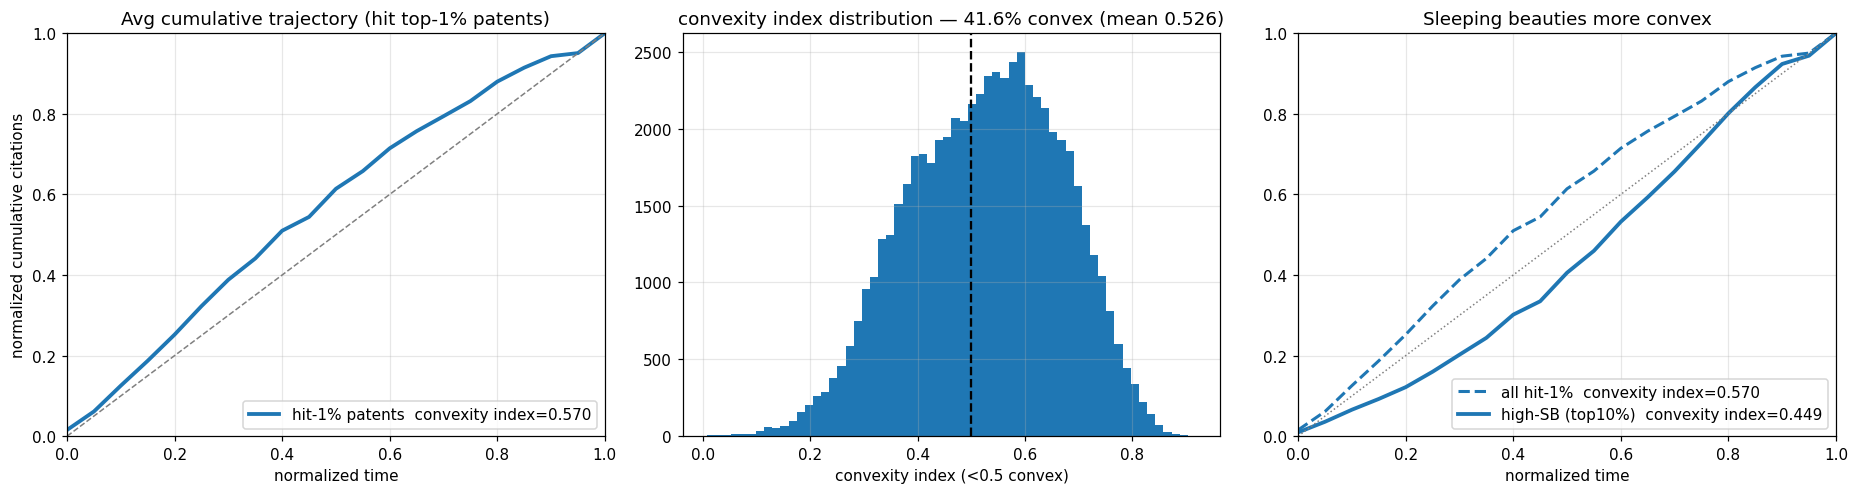

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
ax[0].plot(GX, overall, color=BLUE, lw=2.5, label=f'hit-1% patents  convexity index={aucc(overall):.3f}')
ax[0].plot([0, 1], [0, 1], color='gray', ls='--', lw=1); ax[0].set_title('Avg cumulative trajectory (hit top-1% patents)')
ax[0].set_xlabel('normalized time'); ax[0].set_ylabel('normalized cumulative citations'); ax[0].set_xlim(0, 1); ax[0].set_ylim(0, 1); ax[0].legend(loc='lower right')
ax[1].hist(per['auc'], bins=60, color=BLUE); ax[1].axvline(0.5, color='k', ls='--')
ax[1].set_title(f'convexity index distribution — {(per.auc<0.5).mean()*100:.1f}% convex (mean {per.auc.mean():.3f})'); ax[1].set_xlabel('convexity index (<0.5 convex)')
ax[2].plot(GX, overall, color=BLUE, ls='--', lw=2, label=f'all hit-1%  convexity index={aucc(overall):.3f}')
ax[2].plot(GX, hitraj, color=BLUE, lw=2.5, label=f'high-SB (top10%)  convexity index={aucc(hitraj):.3f}')
ax[2].plot([0, 1], [0, 1], color='gray', ls=':', lw=1); ax[2].set_title('Sleeping beauties more convex')
ax[2].set_xlim(0, 1); ax[2].set_ylim(0, 1); ax[2].legend(loc='lower right'); ax[2].set_xlabel('normalized time')
plt.tight_layout(); plt.show()

### 14b. Convex vs concave (hit top-1%) — by CPC section and group properties

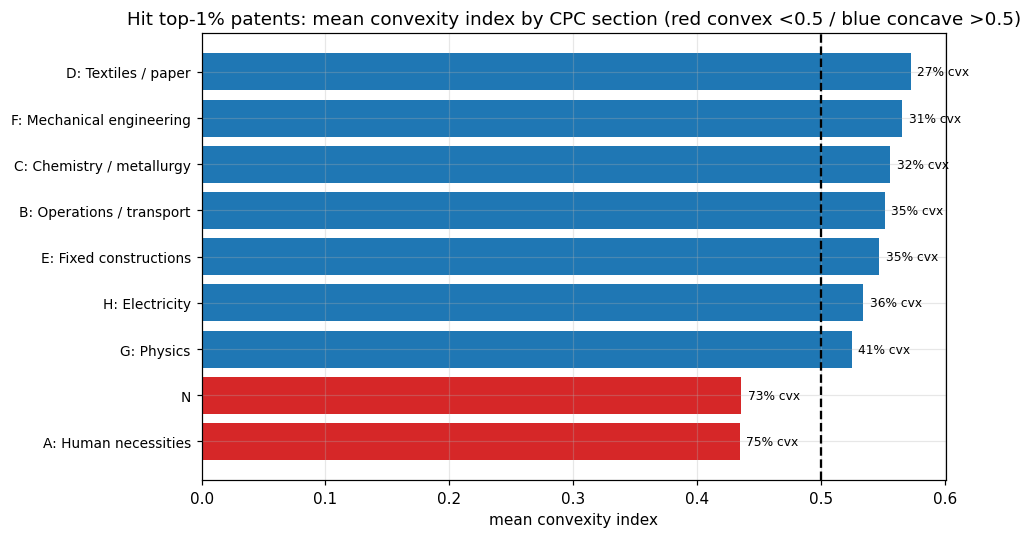

overall (hit top-1%): {'convex%': np.float64(41.6), 'concave%': np.float64(58.4), 'mean_cvx': np.float64(0.526)}
\nconvex vs concave group properties:
             n  mean_cvx  mean_citations  mean_SB_B
shape                                              
concave  35791      0.63          119.96       5.89
convex   25503      0.39          347.70      19.73
\nmean convexity index / %convex by CPC section:


,mean_cvx,pct_convex,n,section_name
cpc_section,,,,
A,0.435,75.323,8660,A: Human necessities
N,0.436,72.727,11,N
G,0.525,40.880,15345,G: Physics
H,0.534,36.135,14064,H: Electricity
E,0.547,35.294,1751,E: Fixed constructions
B,0.551,34.718,9030,B: Operations / transport
C,0.556,31.572,7022,C: Chemistry / metallurgy
F,0.566,30.968,4750,F: Mechanical engineering
D,0.572,26.626,661,D: Textiles / paper


Spearman(SB_B, convexity index) = -0.323  (negative = higher SB -> more convex)
done — patent hit-top-1% convexity analysis rendered inline.


In [18]:
pct_convex = (per['auc'] < 0.5).mean() * 100
CPC_NAMES = {'A': 'A: Human necessities', 'B': 'B: Operations / transport', 'C': 'C: Chemistry / metallurgy',
             'D': 'D: Textiles / paper', 'E': 'E: Fixed constructions', 'F': 'F: Mechanical engineering',
             'G': 'G: Physics', 'H': 'H: Electricity', 'Y': 'Y: Emerging / cross-sectional'}
bys = per.dropna(subset=['cpc_section']).groupby('cpc_section').agg(
    mean_cvx=('auc', 'mean'), pct_convex=('auc', lambda x: (x < 0.5).mean() * 100), n=('auc', 'size')).sort_values('mean_cvx')
bys['section_name'] = [CPC_NAMES.get(s, s) for s in bys.index]
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d62728' if a < 0.5 else '#1f77b4' for a in bys['mean_cvx']]
ax.barh(range(len(bys)), bys['mean_cvx'], color=colors)
ax.set_yticks(range(len(bys))); ax.set_yticklabels(bys['section_name'].values, fontsize=9)
ax.axvline(0.5, color='k', ls='--'); ax.set_xlabel('mean convexity index')
for i, (a, p) in enumerate(zip(bys['mean_cvx'], bys['pct_convex'])):
    ax.text(a + 0.005, i, f'{p:.0f}% cvx', va='center', fontsize=8)
ax.set_title('Hit top-1% patents: mean convexity index by CPC section (red convex <0.5 / blue concave >0.5)')
plt.tight_layout(); plt.show()
print('overall (hit top-1%):', {'convex%': round(pct_convex, 1), 'concave%': round(100 - pct_convex, 1), 'mean_cvx': round(per.auc.mean(), 3)})
print('\\nconvex vs concave group properties:')
print(per.groupby('shape').agg(n=('auc', 'size'), mean_cvx=('auc', 'mean'),
      mean_citations=('tot', 'mean'), mean_SB_B=('SB_B', 'mean')).round(2).to_string())
print('\\nmean convexity index / %convex by CPC section:'); display(bys.round(3))
sp = pd.DataFrame({'sb': per['SB_B'], 'auc': per['auc']}).replace([np.inf, -np.inf], np.nan).dropna()
print(f'Spearman(SB_B, convexity index) = {sp.sb.rank().corr(sp.auc.rank()):+.3f}  (negative = higher SB -> more convex)')
print('done — patent hit-top-1% convexity analysis rendered inline.')

## 15. Cumulative trajectory convexity — EXTENDED network (granted + application citations), hit top-1%

Repeats the §14 convexity test but on the **extended** yearly trajectory: value per year =
`pat2pat_examiner + pat2pat_non_examiner + app2pat_examiner + app2pat_non_examiner` (granted **and**
application/pre-grant citations, from the updated `patent_citation_trend.parquet`). Same hit top-1%
cohort (uniqueC_5 top-1%, shared with §14), same convexity index convexity rule (`<0.5` convex). Compares each patent's granted-only convexity index
(`per`, from §14) against its extended convexity index, so we can see whether adding application citations shifts the
convex/concave verdict. Reuses the open DuckDB connection `con` and the helpers `GX`, `NB`, `aucc`, `overall`.

In [19]:
%%time
TOT = "(pat2pat_examiner+pat2pat_non_examiner+app2pat_examiner+app2pat_non_examiner)"
AGG_E = (f"SELECT patent_id, sum{TOT} tot, max(yrs_since_grant) span "
         f"FROM read_parquet('{TREND}') WHERE patent_id IN (SELECT patent_id FROM hit1) "
         f"GROUP BY patent_id HAVING sum{TOT}>=10 AND max(yrs_since_grant)>=5")
Q_PE = (f"WITH agg AS ({AGG_E}) "
        f"SELECT t.patent_id, a.tot, a.span, "
        f"1 - sum({TOT}*(t.yrs_since_grant::double/a.span))/a.tot AS auc "
        f"FROM read_parquet('{TREND}') t JOIN agg a USING (patent_id) "
        f"GROUP BY t.patent_id, a.tot, a.span")
per_e = con.execute(Q_PE).fetchdf()
per_e = per_e.merge(df[['patent_id', 'cpc_section', 'SB_B']], on='patent_id', how='left')
per_e['shape'] = np.where(per_e['auc'] < 0.5, 'convex', 'concave')

def mean_traj_e(id_series=None):
    where = ''
    if id_series is not None:
        con.register('flte', pd.DataFrame({'patent_id': id_series.values})); where = 'JOIN flte USING (patent_id)'
    q = (f"WITH agg AS ({AGG_E}), j AS ("
         f"SELECT (t.yrs_since_grant::double/a.span) nt, {TOT} v, a.tot, t.patent_id "
         f"FROM read_parquet('{TREND}') t JOIN agg a USING (patent_id) {where}) "
         f"SELECT least(floor(nt*{NB}),{NB}) b, sum(v::double/tot) w FROM j GROUP BY b ORDER BY b")
    h = con.execute(q).fetchdf()
    N = len(id_series) if id_series is not None else len(per_e)
    wv = np.zeros(NB + 1); wv[h['b'].astype(int).values] = h['w'].values
    return np.cumsum(wv) / N

overall_e = mean_traj_e()
print(f'extended hit-1% patents with trajectory: {len(per_e):,}')
print(f'granted-only : {(per.auc<0.5).mean()*100:5.1f}% convex, mean convexity index {per.auc.mean():.3f}')
print(f'extended     : {(per_e.auc<0.5).mean()*100:5.1f}% convex, mean convexity index {per_e.auc.mean():.3f}')

extended hit-1% patents with trajectory: 69,256
granted-only :  41.6% convex, mean convexity index 0.526
extended     :  35.4% convex, mean convexity index 0.547
CPU times: total: 10.8 s
Wall time: 3.58 s


<timed exec>:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.


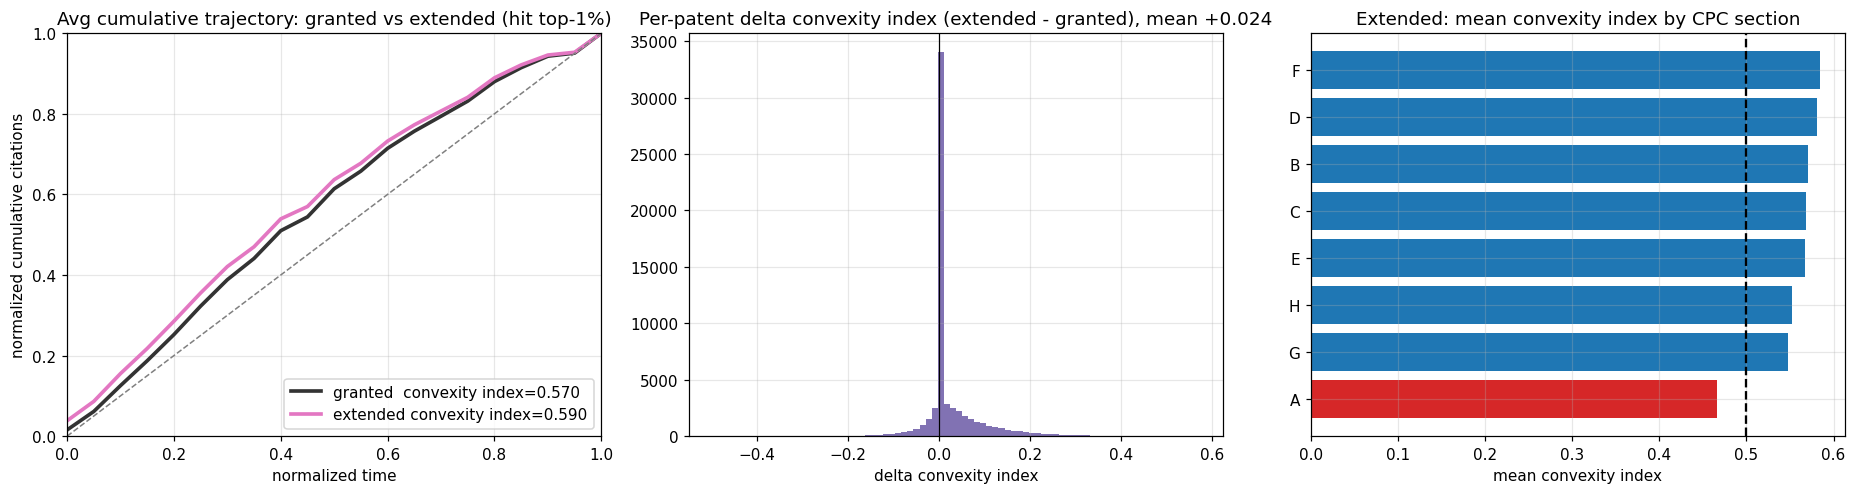

per-patent convexity index delta: 14.4% more convex, 37.7% more concave (mean delta +0.0235)
Spearman(granted convexity index, extended convexity index): 0.8829
verdict flipped (convex<->concave) for 10.8% of patents (common cohort n=61,294)

extended convex vs concave group properties:
             n  mean_cvx  mean_citations  mean_SB_B
shape                                              
concave  44761      0.62          188.47   5.770000
convex   24495      0.41          483.84  19.879999

extended: mean convexity index / %convex by CPC section:


,mean_cvx,pct_convex,n
cpc_section,,,
A,0.466,64.054,8802
G,0.547,35.137,17776
H,0.552,31.315,16928
E,0.567,29.478,1876
C,0.569,28.895,7773
B,0.570,29.637,10045
D,0.581,23.983,713
F,0.584,25.187,5217


done — extended-network convexity (granted + application) rendered inline.
CPU times: total: 219 ms
Wall time: 252 ms


In [20]:
%%time
cmp = per[['patent_id', 'auc']].rename(columns={'auc': 'auc_g'}).merge(
      per_e[['patent_id', 'auc']].rename(columns={'auc': 'auc_e'}), on='patent_id')
dd = cmp['auc_e'] - cmp['auc_g']
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
ax[0].plot(GX, overall, color='#333333', lw=2.4, label=f'granted  convexity index={aucc(overall):.3f}')
ax[0].plot(GX, overall_e, color='#e377c2', lw=2.4, label=f'extended convexity index={aucc(overall_e):.3f}')
ax[0].plot([0, 1], [0, 1], color='gray', ls='--', lw=1); ax[0].set_xlim(0, 1); ax[0].set_ylim(0, 1)
ax[0].set_title('Avg cumulative trajectory: granted vs extended (hit top-1%)')
ax[0].set_xlabel('normalized time'); ax[0].set_ylabel('normalized cumulative citations'); ax[0].legend(loc='lower right')
ax[1].hist(dd.values, bins=80, color='#8172b3'); ax[1].axvline(0, color='k', lw=0.8)
ax[1].set_title(f'Per-patent delta convexity index (extended - granted), mean {dd.mean():+.3f}'); ax[1].set_xlabel('delta convexity index')
byse = per_e.dropna(subset=['cpc_section']).groupby('cpc_section').agg(
    mean_cvx=('auc', 'mean'), pct_convex=('auc', lambda x: (x < 0.5).mean() * 100), n=('auc', 'size')).sort_values('mean_cvx')
byse = byse[byse.index.isin(list('ABCDEFGHY'))]
colors = ['#d62728' if a < 0.5 else '#1f77b4' for a in byse['mean_cvx']]
ax[2].barh(range(len(byse)), byse['mean_cvx'], color=colors)
ax[2].set_yticks(range(len(byse))); ax[2].set_yticklabels(byse.index)
ax[2].axvline(0.5, color='k', ls='--'); ax[2].set_xlabel('mean convexity index')
ax[2].set_title('Extended: mean convexity index by CPC section')
plt.tight_layout(); plt.show()
print(f'per-patent convexity index delta: {100*(dd<0).mean():.1f}% more convex, {100*(dd>0).mean():.1f}% more concave '
      f'(mean delta {dd.mean():+.4f})')
print('Spearman(granted convexity index, extended convexity index):', round(cmp[['auc_g', 'auc_e']].corr(method='spearman').iloc[0, 1], 4))
flip = (cmp['auc_g'] < 0.5) != (cmp['auc_e'] < 0.5)
print(f'verdict flipped (convex<->concave) for {100*flip.mean():.1f}% of patents (common cohort n={len(cmp):,})')
print('\nextended convex vs concave group properties:')
print(per_e.groupby('shape').agg(n=('auc', 'size'), mean_cvx=('auc', 'mean'),
      mean_citations=('tot', 'mean'), mean_SB_B=('SB_B', 'mean')).round(2).to_string())
print('\nextended: mean convexity index / %convex by CPC section:'); display(byse.round(3))
print('done — extended-network convexity (granted + application) rendered inline.')

## 16. Yearly-trend convexity — Disruption / F / E / G / ni / nj / nk (overall & by CPC section)

Applies the same min–max + convexity index test to the **time trend** of each metric (mean value by grant year):
each metric's yearly series is min–max scaled on both axes and its **convexity index** is measured (`<0.5` **convex**
= accelerating / late upturn; `>0.5` **concave** = early rise then flattening). Computed overall and for
each **CPC section**. Uses `patent_disruption` ⋈ `patent_metadata` (grant year in a truncation-safe range).

In [21]:
%%time
DISRP = os.path.join(POUT, 'patent_disruption.parquet').replace(os.sep, '/')
METAP = os.path.join(POUT, 'patent_metadata.parquet').replace(os.sep, '/')
METR = ['CD_5', 'F_5', 'E_5', 'G_5', 'ni_5', 'nj_5', 'nk_5']
YR0, YR1 = 1980, 2015                       # avoid the most citation-truncated recent years
avgs = ', '.join([f'avg(d.{m}) {m}' for m in METR])
ov = con.execute(f'''SELECT m.grant_year AS yr, {avgs}
  FROM read_parquet('{DISRP}') d JOIN read_parquet('{METAP}') m USING (patent_id)
  WHERE d.CD_5 IS NOT NULL AND m.grant_year BETWEEN {YR0} AND {YR1}
  GROUP BY yr ORDER BY yr''').fetchdf()
bysec = con.execute(f'''SELECT m.grant_year AS yr, substr(m.cpc_code,1,1) AS secn, count(*) n, {avgs}
  FROM read_parquet('{DISRP}') d JOIN read_parquet('{METAP}') m USING (patent_id)
  WHERE d.CD_5 IS NOT NULL AND m.grant_year BETWEEN {YR0} AND {YR1} AND m.cpc_code IS NOT NULL
  GROUP BY yr, secn ORDER BY secn, yr''').fetchdf()

def trend_auc(t, y):
    t = np.asarray(t, float); y = np.asarray(y, float); ok = np.isfinite(y)
    t, y = t[ok], y[ok]
    if len(y) < 6 or y.max() == y.min(): return np.nan
    tn = (t - t.min()) / (t.max() - t.min()); yn = (y - y.min()) / (y.max() - y.min())
    return float(np.trapz(yn, tn))

print(f'overall yearly-trend convexity index per metric ({YR0}-{YR1}; <0.5 convex / >0.5 concave):')
for m in METR:
    a = trend_auc(ov['yr'].values, ov[m].values)
    print(f'  {m:8s} convexity index {a:.3f}  ({"convex" if a < 0.5 else "concave"})')

overall yearly-trend convexity index per metric (1980-2015; <0.5 convex / >0.5 concave):
  CD_5     convexity index 0.236  (convex)
  F_5      convexity index 0.553  (concave)
  E_5      convexity index 0.657  (concave)
  G_5      convexity index 0.309  (convex)
  ni_5     convexity index 0.428  (convex)
  nj_5     convexity index 0.524  (concave)
  nk_5     convexity index 0.314  (convex)
CPU times: total: 3.69 s
Wall time: 574 ms


<timed exec>:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.


### 16a. Overall metric trends (min–max scaled) + convexity

<timed exec>:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.


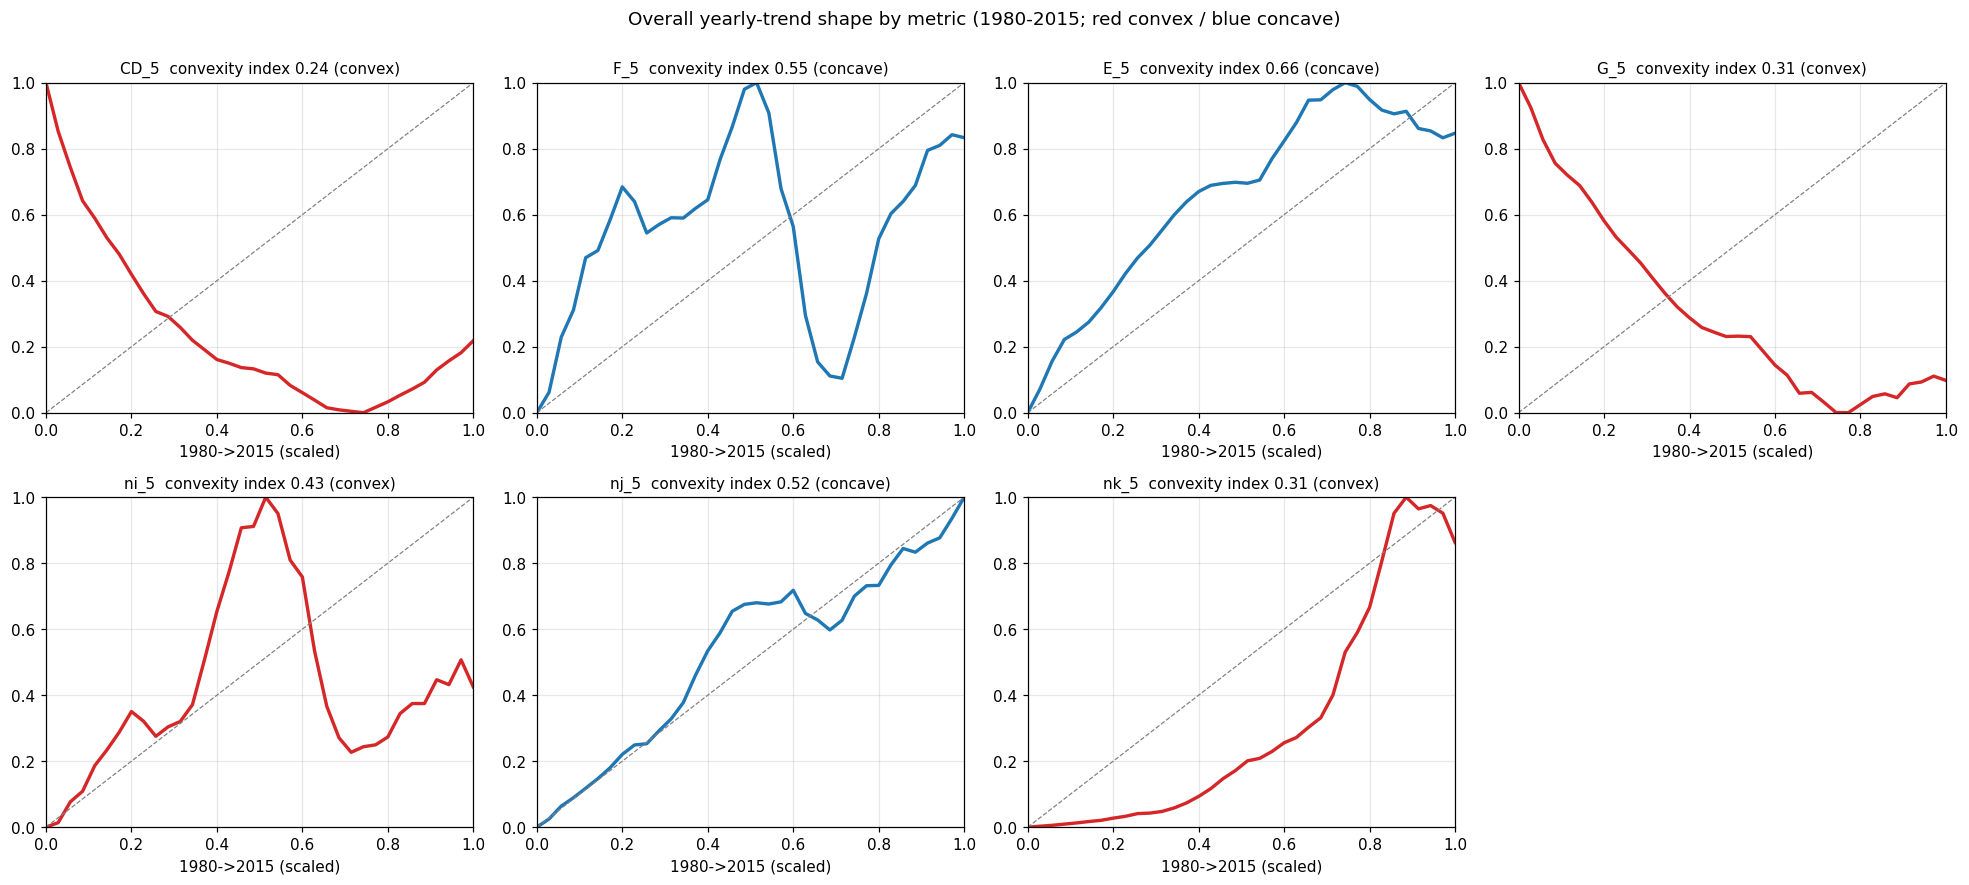

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, m in zip(axes.flat, METR):
    t = ov['yr'].values.astype(float); y = ov[m].values.astype(float)
    tn = (t - t.min()) / (t.max() - t.min()); yn = (y - np.nanmin(y)) / (np.nanmax(y) - np.nanmin(y))
    a = trend_auc(t, y); col = '#d62728' if a < 0.5 else '#1f77b4'
    ax.plot(tn, yn, color=col, lw=2.2); ax.plot([0, 1], [0, 1], color='gray', ls='--', lw=0.8)
    ax.set_title(f'{m}  convexity index {a:.2f} ({"convex" if a < 0.5 else "concave"})', fontsize=10)
    ax.set_xlabel(f'{YR0}->{YR1} (scaled)'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
axes.flat[-1].set_visible(False)
fig.suptitle(f'Overall yearly-trend shape by metric ({YR0}-{YR1}; red convex / blue concave)', y=1.0)
plt.tight_layout(); plt.show()

### 16b. Convexity of yearly trends by CPC section (convexity index heatmap)

<timed exec>:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.


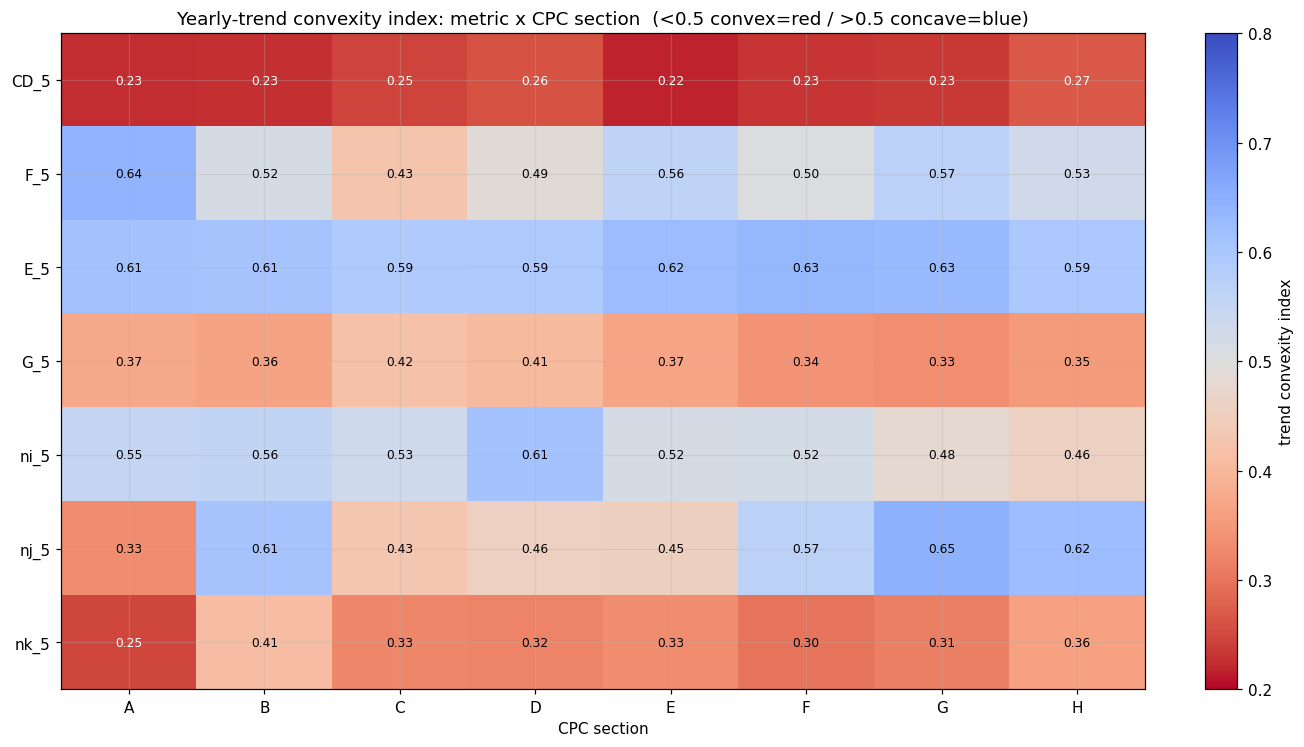

trend convexity index by metric x CPC section:


,A,B,C,D,E,F,G,H
CD_5,0.225,0.227,0.246,0.261,0.218,0.231,0.234,0.267
F_5,0.640,0.518,0.426,0.493,0.562,0.503,0.569,0.530
E_5,0.608,0.608,0.591,0.592,0.624,0.635,0.629,0.594
G_5,0.375,0.364,0.419,0.406,0.368,0.341,0.334,0.352
ni_5,0.552,0.555,0.531,0.608,0.518,0.519,0.483,0.459
nj_5,0.332,0.607,0.431,0.458,0.455,0.566,0.647,0.620
nk_5,0.248,0.412,0.325,0.322,0.332,0.299,0.313,0.364


done — yearly-trend convexity (overall & by CPC section) rendered inline.


In [23]:
secs = [s for s in list('ABCDEFGHY') if s in set(bysec['secn'].dropna().unique())]
Hmat = np.full((len(METR), len(secs)), np.nan)
for j, sc in enumerate(secs):
    g = bysec[bysec['secn'] == sc].sort_values('yr')
    if g['n'].sum() < 500:
        continue
    for i, m in enumerate(METR):
        Hmat[i, j] = trend_auc(g['yr'].values, g[m].values)
fig, ax = plt.subplots(figsize=(1.0 * len(secs) + 4, 0.7 * len(METR) + 2))
im = ax.imshow(Hmat, cmap='coolwarm_r', vmin=0.2, vmax=0.8, aspect='auto')   # <0.5 convex=red, >0.5 concave=blue
ax.set_xticks(range(len(secs))); ax.set_xticklabels(secs)
ax.set_yticks(range(len(METR))); ax.set_yticklabels(METR)
for i in range(len(METR)):
    for j in range(len(secs)):
        if np.isfinite(Hmat[i, j]):
            ax.text(j, i, f'{Hmat[i, j]:.2f}', ha='center', va='center', fontsize=8,
                    color='white' if abs(Hmat[i, j] - 0.5) > 0.22 else 'black')
ax.set_title('Yearly-trend convexity index: metric x CPC section  (<0.5 convex=red / >0.5 concave=blue)')
fig.colorbar(im, fraction=0.046, label='trend convexity index')
ax.set_xlabel('CPC section'); plt.tight_layout(); plt.show()
summ = pd.DataFrame(Hmat, index=METR, columns=secs)
print('trend convexity index by metric x CPC section:'); display(summ.round(3))
print('done — yearly-trend convexity (overall & by CPC section) rendered inline.')

## 17. Team size (inventors) -> disruption percentile & impact (Wu et al. Fig 2a style)

Patent analogue of the paper Fig 2a: **team size = number of inventors** (`inventor_list`), **impact =
patent->patent citations (`C_5`)**, disruption = percentile of `CD_5`. Small teams should disrupt more,
large teams should be cited more. Grant years 1980-2015, `ref_count>=1`, inventors 1-10.

 team_size       dis   dis_ci      cit   cit_ci       n
         1 47.508416 0.047570 3.693020 0.011930 1656589
         2 46.981417 0.056996 4.347132 0.018700 1070091
         3 46.514278 0.069877 4.761203 0.026713  679627
         4 46.303397 0.091661 5.028891 0.037215  384342
         5 45.832260 0.127209 5.445517 0.058554  195858
         6 45.517802 0.176092 5.804797 0.089154  102022
         7 44.762606 0.241792 6.115969 0.126179   52626
         8 44.684981 0.329648 6.448061 0.193790   28572
         9 44.081107 0.449565 6.726511 0.248221   15401
        10 43.992565 0.569293 7.736298 0.482215    9488


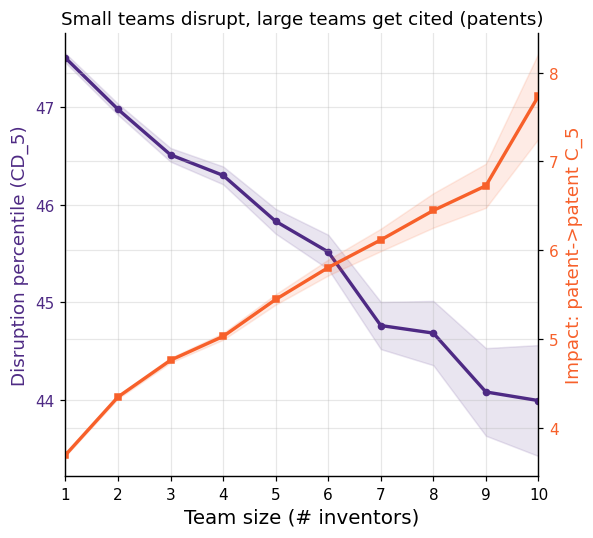

done — patent team-size Fig 2a rendered inline.
CPU times: total: 5.16 s
Wall time: 821 ms


In [24]:
%%time
DISRp = os.path.join(POUT, 'patent_disruption.parquet').replace(os.sep, '/')
CITp = os.path.join(POUT, 'patent_citation.parquet').replace(os.sep, '/')
METAp = os.path.join(POUT, 'patent_metadata.parquet').replace(os.sep, '/')
q = f'''
WITH base AS (
  SELECT d.CD_5, c.C_5, len(str_split(m.inventor_list, ';')) AS team_size
  FROM read_parquet('{DISRp}') d
  JOIN read_parquet('{CITp}') c USING (patent_id)
  JOIN read_parquet('{METAp}') m USING (patent_id)
  WHERE d.CD_5 IS NOT NULL AND m.inventor_list IS NOT NULL
    AND m.ref_count >= 1 AND m.grant_year BETWEEN 1980 AND 2015),
filt AS (SELECT * FROM base WHERE team_size BETWEEN 1 AND 10),
ranked AS (SELECT team_size, C_5, percent_rank() OVER (ORDER BY CD_5) AS dpct FROM filt)
SELECT team_size, avg(dpct)*100 AS dis, 1.96*stddev(dpct)/sqrt(count(*))*100 AS dis_ci,
       avg(C_5) AS cit, 1.96*stddev(C_5)/sqrt(count(*)) AS cit_ci, count(*) AS n
FROM ranked GROUP BY team_size ORDER BY team_size'''
g = con.execute(q).fetchdf(); print(g.to_string(index=False))
x = g['team_size'].values; c1, c2 = '#4E2A84', '#F7602A'
fig, ax = plt.subplots(figsize=(5.5, 5)); ax2 = ax.twinx()
ax.plot(x, g['dis'], color=c1, lw=2.2, marker='o', ms=4)
ax2.plot(x, g['cit'], color=c2, lw=2.2, marker='s', ms=4)
ax.fill_between(x, g['dis'] - g['dis_ci'], g['dis'] + g['dis_ci'], color=c1, alpha=0.12)
ax2.fill_between(x, g['cit'] - g['cit_ci'], g['cit'] + g['cit_ci'], color=c2, alpha=0.12)
ax.set_xlabel('Team size (# inventors)', size=13)
ax.set_ylabel('Disruption percentile (CD_5)', size=12, color=c1); ax2.set_ylabel('Impact: patent->patent C_5', size=12, color=c2)
ax.tick_params(axis='y', labelcolor=c1); ax2.tick_params(axis='y', labelcolor=c2)
ax.set_xlim(1, 10); ax.spines['top'].set_visible(False); ax2.spines['top'].set_visible(False)
ax.set_title('Small teams disrupt, large teams get cited (patents)')
plt.tight_layout(); plt.show()
print('done — patent team-size Fig 2a rendered inline.')

## 18. Atypicality Z-score CDF (reference style: 10th-pct & Median)

In [25]:
%%time
import matplotlib.ticker as _tk
MIN_N = 1000

def find_nearest(array, value):
    array = np.asarray(array)
    return int((np.abs(array - value)).argmin())

def plot_atyp_cdf(df_, col_10pct, col_median, title,
                  ylabel='CDF of journal papers',
                  label1=r'$10^{\rm th}$ percentile $Z$-score', label2=r'Median $Z$-score'):
    """CDF of Atyp Z-scores at 24 thresholds: 8 neg (-2^8..-2^1) | 0 | 15 pos (2^1..2^15)."""
    plt.rcParams['text.usetex'] = False
    label_x1 = np.array([(x + 1) for x in range(8)])[::-1]
    label_x2 = np.array([0])
    label_x3 = np.array([(x + 1) for x in range(15)])
    label_x = np.concatenate((label_x1, label_x2, label_x3))
    atyp_x = np.arange(1, 25)

    def myticks(x, pos):
        i = int(round(x)) - 1
        if i < 0 or i >= len(label_x): return ''
        v = label_x[i]
        if x < 9:
            return r'$-2^{%d}$' % v if int(round(x)) % 2 != 0 else ''
        elif x == 9:
            return r'$0$'
        else:
            return r'$2^{%d}$' % v if int(round(x)) % 2 != 0 else ''

    def compute_cdf(col):
        if col not in df_.columns:
            print(f'  [skip] {col} not in data'); return None
        vals = df_[col].replace([np.inf, -np.inf], np.nan).dropna().values
        if len(vals) < MIN_N: return None
        zs = np.sort(vals)
        pos1 = np.array([find_nearest(zs, -2 ** (x + 1)) for x in range(8)])[::-1]
        pos2 = np.array([find_nearest(zs, 0)])
        pos3 = np.array([find_nearest(zs, 2 ** (x + 1)) for x in range(15)])
        return np.concatenate((pos1, pos2, pos3)) / len(zs)

    pct_p = compute_cdf(col_10pct); pct_p2 = compute_cdf(col_median)
    if pct_p is None and pct_p2 is None:
        print(f'  [skip plot] no data for {col_10pct!r} / {col_median!r}'); return
    fig, ax = plt.subplots(dpi=150)
    if pct_p is not None:
        ax.plot(atyp_x, pct_p, 'o-', ms=9, markeredgewidth=2, lw=2, label=label1, markerfacecolor='none', alpha=0.7)
    if pct_p2 is not None:
        ax.plot(atyp_x, pct_p2, 'o-', ms=9, markeredgewidth=2, lw=2, label=label2, markerfacecolor='none', alpha=0.7)
    ax.xaxis.set_major_locator(_tk.IndexLocator(base=1, offset=0))
    ax.yaxis.set_minor_locator(_tk.IndexLocator(base=0.1, offset=0))
    ax.tick_params(axis='x', labelsize=12); ax.tick_params(axis='y', labelsize=12)
    ax.set_xlabel(r'$Z$-score', fontsize=16); ax.set_ylabel(ylabel, fontsize=16)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_formatter(_tk.FuncFormatter(myticks))
    ax.set_title(title, fontsize=12)
    ax.legend(loc=0, numpoints=1, fontsize=12, frameon=False)
    plt.tight_layout(); plt.show()

CPU times: total: 0 ns
Wall time: 0 ns


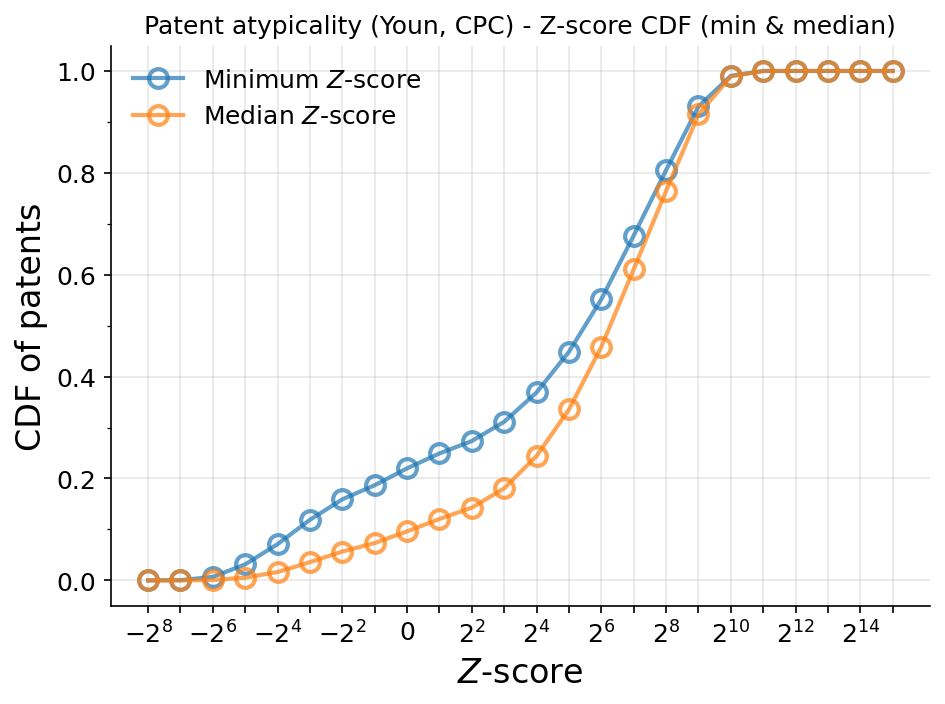

          Z_median        Z_min
count  4160856.000  4160856.000
mean       170.913      139.621
std        230.848      224.168
min       -185.342     -192.618
25%         16.820        2.068
50%         77.542       46.110
75%        240.417      188.947
max       1522.201     1522.201
CPU times: total: 1.27 s
Wall time: 1.29 s


In [26]:
%%time
zz = pd.read_parquet(os.path.join(POUT, 'patent_z_score.parquet'), columns=['Z_median', 'Z_min'])
plot_atyp_cdf(zz, 'Z_min', 'Z_median', 'Patent atypicality (Youn, CPC) - Z-score CDF (min & median)', ylabel='CDF of patents', label1=r'Minimum $Z$-score')
print(zz[['Z_median', 'Z_min']].describe().round(3).to_string())

## 19. Atypicality 2x2 - hit-patent probability (Youn CPC atypicality)

In [27]:
%%time
from mpl_toolkits.mplot3d import Axes3D  # noqa

def plot_2x2(zmed, znov, hit, title, zlabel='Hit paper probability'):
    # zmed = median conventionality (higher = more conventional); znov = tail novelty score (LOWER = more novel)
    zmed = np.asarray(zmed, float); znov = np.asarray(znov, float); hit = np.asarray(hit, float)
    m = np.isfinite(zmed) & np.isfinite(znov) & np.isfinite(hit)
    zmed, znov, hit = zmed[m], znov[m], hit[m]
    hc = zmed >= np.median(zmed)            # high median conventionality
    hn = znov <= np.median(znov)            # high tail novelty (lower Z = more novel)
    cells = {('LowConv', 'LowNov'): (~hc) & (~hn), ('LowConv', 'HighNov'): (~hc) & hn,
             ('HighConv', 'LowNov'): hc & (~hn), ('HighConv', 'HighNov'): hc & hn}
    P4 = {k: hit[v].mean() for k, v in cells.items()}
    fig = plt.figure(figsize=(9, 6)); ax = fig.add_subplot(projection='3d')
    xpos = np.array([0, 1, 0, 1]); ypos = np.array([0, 0, 1, 1]); zpos = np.zeros(4)
    dz = [P4[('LowConv', 'LowNov')], P4[('LowConv', 'HighNov')], P4[('HighConv', 'LowNov')], P4[('HighConv', 'HighNov')]]
    ax.bar3d(xpos, ypos, zpos, 0.6, 0.6, dz, color=['red', 'orange', 'green', 'blue'], zsort='average')
    ax.set_xticks([0.3, 1.3]); ax.set_xticklabels(['Low Tail\nNovelty', 'High Tail\nNovelty'], fontsize=9)
    ax.set_yticks([0.3, 1.3]); ax.set_yticklabels(['Low Median\nConvention', 'High Median\nConvention'], fontsize=9)
    ax.set_zlabel(zlabel, fontsize=12); ax.set_title(title, fontsize=11); ax.view_init(20, -45)
    for pane in (ax.xaxis, ax.yaxis, ax.zaxis): pane.pane.fill = False
    plt.tight_layout(); plt.show()
    print(title, '-> hit prob per cell:', {f'{a}|{b}': round(p, 4) for (a, b), p in P4.items()})

CPU times: total: 0 ns
Wall time: 0 ns


<timed exec>:21: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.


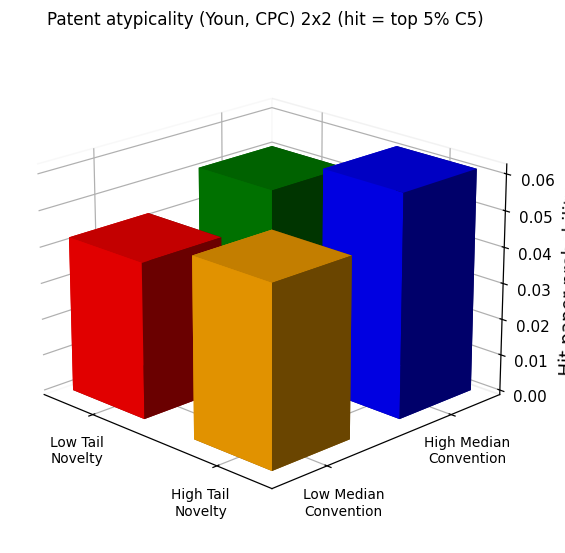

Patent atypicality (Youn, CPC) 2x2 (hit = top 5% C5) -> hit prob per cell: {'LowConv|LowNov': np.float64(0.0428), 'LowConv|HighNov': np.float64(0.0494), 'HighConv|LowNov': np.float64(0.0512), 'HighConv|HighNov': np.float64(0.0614)}
CPU times: total: 5.53 s
Wall time: 5.54 s


In [28]:
%%time
zc = pd.read_parquet(os.path.join(POUT, 'patent_z_score.parquet'), columns=['patent_id', 'Z_median', 'Z_10pct'])
zc = zc.merge(df[['patent_id', 'pctl_c5']], on='patent_id', how='inner')
hitp = (zc['pctl_c5'] >= 0.95).astype(float).values
plot_2x2(zc['Z_median'].values, zc['Z_10pct'].values, hitp, 'Patent atypicality (Youn, CPC) 2x2 (hit = top 5% C5)')